# Machine Learning - CA2  
## Neural Networks and Semantic Analysis

**Student:** Thiago Gonçalves da Costa — **2022161**  
**College:** CCT College Dublin  
**Programme:** BSc (Hons) in Computing and IT — Year 4  
**Module:** Machine Learning for AI  
**Assessment:** ML_CA2  
**Lecturer:** David McQuaid  
**Submission Deadline:** 31st May 2026  

## Introduction

This project is divided into two main parts: **Neural Network Regression** and **Semantic / Sentiment Analysis**.

The first part uses the `international-visitors-london.csv` dataset. The main objective is to prepare and analyse the data, then build machine learning models to predict visitor spending in London. The target variable for this task is **Spend (£m)**. Because this target is a continuous numerical value, this part of the project is a supervised regression problem.

In this section, I will build a Neural Network model and compare it with at least one standard machine learning regression model. The models will be tested and evaluated to understand which one performs better for this dataset. A prediction will also be made for a new visitor segment that is not already in the original dataset.

The second part of the project uses social media text data to perform sentiment analysis. The text observations will be classified as **positive**, **neutral**, or **negative**. The overall sentiment distribution will then be visualised using Python.

All data preparation, analysis, modelling, evaluation, visualisation, and written discussion are completed in this Jupyter Notebook using Python and Markdown.

## Project Methodology


This project follows the general workflow covered in class: understanding the problem, understanding the data, preparing the data, building models, evaluating the results, and discussing the final findings (McQuaid, 2026o).

This structure helps to keep the notebook organised and makes sure that the data is explored and prepared before any modelling is done.

For the regression part, this means loading and understanding the London visitors dataset, cleaning and preparing the data, building regression models, comparing their results, and making a final prediction.

For the sentiment analysis part, this means preparing a social media text dataset, classifying the text as positive, neutral, or negative, visualising the sentiment distribution, and discussing the findings.

# Part 1 — Spend (£m) Prediction

## Business Understanding

The first part of this project focuses on predicting visitor spending in London using the `international-visitors-london.csv` dataset.

The main business problem is to understand and predict how much different international visitor segments spend in London. In the dataset, this is represented by the target variable **Spend (£m)**.

Visitor spending is important because it helps to understand the economic value of international tourism in London. If spending can be predicted from visitor characteristics, it can help tourism analysts and businesses understand which types of visitor segments are linked with higher or lower spending.

For example, spending may be affected by factors such as the visitor market, quarter of the year, duration of stay, mode of transport, purpose of visit, number of visits, and number of nights.

From a machine learning point of view, this is a **supervised regression problem**. It is supervised because the dataset already contains the target values, and it is regression because **Spend (£m)** is a continuous numerical value.

The machine learning objective is to build models that can predict **Spend (£m)** using the available visitor segment features. In this project, I will train a Neural Network model and compare it with at least one standard machine learning regression model, as required in the assessment brief.

An important point is that each row in this dataset does not represent one individual visitor. Instead, each row represents an aggregated visitor segment. For example, a row may describe visitors from a specific market, during a specific quarter, travelling for a specific purpose, using a specific mode of transport, and staying for a certain duration.

Because of this, when this notebook later makes a prediction for a "new visitor", it will be treated as a prediction for a new visitor segment, not for one individual person. This is more suitable for the structure of the dataset.

The success of the models will be evaluated by comparing predicted spending with the real spending values in the test set. Regression metrics such as MAE, MSE, RMSE, and R² will be used to compare the models and help decide which model performs better.

The final aim of this part is to prepare the data, build and test regression models, compare their results, select a suitable final model, and use it to predict the **Spend (£m)** for a new visitor segment.

## Import Libraries

Before loading and analysing the dataset, the Python libraries needed for this project are imported.

The main libraries used are:

- **pandas** and **numpy** for loading, handling and preparing the data;
- **matplotlib** and **seaborn** for data visualisation;
- **scikit-learn** for data preparation, standard machine learning regression models, train/test split, scaling and evaluation metrics;
- **TensorFlow / Keras** for building the Neural Network model later in the project.

The first parts of the notebook were initially developed on a Mac environment, where TensorFlow/Keras was not loading correctly. The project was then continued on a Windows environment, where TensorFlow/Keras was imported and executed properly.

This allows the Neural Network section to be completed using the same notebook structure.

This allows the data loading, data understanding, data preparation, exploratory analysis and standard regression modelling stages to continue without stopping the notebook (McQuaid, 2026g; McQuaid, 2026k; McQuaid, 2026a).

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Data preparation and model evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Standard machine learning regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Neural Network model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Display settings
pd.set_option("display.max_columns", None)

## Load Dataset

The dataset used for this part of the project is `international-visitors-london.csv`.

In this step, the dataset is loaded into a pandas DataFrame so it can be explored, cleaned, prepared and later used for modelling. This follows the class approach of first reading the data into a DataFrame before checking the structure, data types and summary statistics (McQuaid, 2026g).

The file is loaded using `latin1` encoding because the dataset contains the pound symbol in the target column **Spend (£m)**. Using this encoding avoids possible reading errors when loading the CSV file.

In [2]:
# Load the London visitors dataset
df = pd.read_csv("international-visitors-london.csv", encoding="latin1")

# Display the first five rows
df.head()

,year,quarter,market,dur_stay,mode,purpose,area,Visits (000s),Spend (£m),Nights (000s),sample
0,2002,January-March,Belgium,1-3 nights,Air,Holiday,LONDON,3.572186,0.969138,6.954456,5
1,2002,January-March,Belgium,1-3 nights,Air,Business,LONDON,9.284226,2.399577,12.604959,19
2,2002,January-March,Belgium,1-3 nights,Air,VFR,LONDON,0.877182,0.089833,2.153128,3
3,2002,January-March,Belgium,1-3 nights,Air,Miscellaneous,LONDON,0.163874,0.010160,0.163874,1
4,2002,January-March,Belgium,1-3 nights,Sea,Business,LONDON,1.648670,0.016789,1.650300,1


The first five rows were displayed to get an initial view of the dataset before starting the data understanding stage.

From the output, the dataset contains categorical columns such as year, quarter, market, duration of stay, mode, purpose, and area. It also contains numerical columns such as Visits (000s), Spend (£m), Nights (000s), and sample.

The target variable for this regression task is Spend (£m).

## Data Understanding

In this section, I will explore the structure of the London visitors dataset before doing any cleaning, preparation or modelling.

This step is important because the dataset needs to be understood before choosing the correct preparation steps and models. In the class materials, the data understanding stage includes describing the data, exploring the data and checking its quality before moving to data preparation and modelling (McQuaid, 2026o).

The main checks in this section are:

- the number of rows and columns;
- the column names;
- the data types;
- numerical summary statistics;
- categorical summary statistics;
- the number of unique values in each column;
- the distribution of the main categorical variables;
- the target variable for the regression task.

### Dataset Shape

First, I will check the shape of the dataset. This shows how many rows and columns are available in the DataFrame.

Checking the shape is useful because it gives an initial idea of the size of the dataset before starting data preparation or modelling.

In [3]:
# Check the number of rows and columns
df.shape

(61462, 11)

The dataset shape shows that there are **61,462 rows** and **11 columns**.

This means the dataset has a good number of observations for a regression task. Each row represents an aggregated visitor segment, and each column represents information about that segment.

### Column Names

Next, I will check the column names in the dataset. This helps to identify the available features and the target variable.

In [4]:
# Display the column names
df.columns

Index(['year', 'quarter', 'market', 'dur_stay', 'mode', 'purpose', 'area',
       'Visits (000s)', 'Spend (£m)', 'Nights (000s)', 'sample'],
      dtype='object')

The dataset contains columns related to the time period, visitor market, stay duration, travel mode, purpose, area, visits, spend, nights and sample size.

The target variable for this part of the project is **Spend (£m)** because the objective is to predict visitor spending.

### Dataset Information

Next, I will use `info()` to check the data types and the number of non-null values in each column.

This follows the class approach of using pandas to inspect the structure of the DataFrame before modelling (McQuaid, 2026g).

In [5]:
# Check data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61462 entries, 0 to 61461
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           61462 non-null  object 
 1   quarter        61462 non-null  object 
 2   market         61462 non-null  object 
 3   dur_stay       61462 non-null  object 
 4   mode           61462 non-null  object 
 5   purpose        61462 non-null  object 
 6   area           61462 non-null  object 
 7   Visits (000s)  61462 non-null  float64
 8   Spend (£m)     61462 non-null  float64
 9   Nights (000s)  61462 non-null  float64
 10  sample         61462 non-null  int64  
dtypes: float64(3), int64(1), object(7)
memory usage: 5.2+ MB


The `info()` output shows that the dataset has **61,462 entries** and **11 columns**.

The dataset contains both categorical and numerical variables. The categorical columns are stored as object data types, while the numerical columns are stored as float or integer data types.

The output also shows that all columns have 61,462 non-null values. This means that, at this initial stage, there are no missing values visible in the dataset.

### Data Types

I will now display only the data types. This makes it easier to separate categorical columns from numerical columns.

In [6]:
# Display data types
df.dtypes

year              object
quarter           object
market            object
dur_stay          object
mode              object
purpose           object
area              object
Visits (000s)    float64
Spend (£m)       float64
Nights (000s)    float64
sample             int64
dtype: object

The data types show that the dataset contains object columns and numerical columns.

The object columns are mainly categorical variables, such as year, quarter, market, duration of stay, mode, purpose, and area.

The numerical columns are Visits (000s), Spend (£m), Nights (000s), and sample.

The year column is stored as an object instead of an integer. This will need to be checked later because the dataset contains a value called 2020P, which is not a normal numeric year.

### Numerical Summary Statistics

Next, I will use `describe()` to summarise the numerical columns.

This gives the count, mean, standard deviation, minimum, quartiles and maximum values for the numerical variables. This helps to understand the scale of the numeric features and the target variable before modelling.

In [7]:
# Summary statistics for numerical columns
df.describe()

,Visits (000s),Spend (£m),Nights (000s),sample
count,61462.000000,61462.000000,61462.000000,61462.000000
mean,4.927651,3.086634,30.300852,6.099021
std,10.061362,7.243874,61.898302,13.335820
min,0.000103,0.000000,0.000309,1.000000
25%,0.822888,0.321693,3.901581,1.000000
50%,1.797305,1.047351,10.676935,2.000000
75%,4.416618,3.007542,29.483044,5.000000
max,187.487282,373.232590,2492.178513,299.000000


The numerical summary shows the main statistics for Visits (000s), Spend (£m), Nights (000s), and sample.

The target variable Spend (£m) has a much higher maximum value than its median value. This suggests that the spending data may be right-skewed, with many lower values and some very high values.

The same pattern can also be seen in variables such as Visits (000s) and Nights (000s), where the maximum values are much larger than the median values. This will be explored more during the visualisation stage.

### Categorical Summary Statistics

The normal `describe()` function mainly summarises numerical columns. For categorical columns, I will use `describe(include='object')`.

This follows the pandas class material, where `describe(include=object)` is used to summarise categorical variables separately from numerical variables (McQuaid, 2026g).

In [8]:
# Summary statistics for categorical columns
df.describe(include="object")

,year,quarter,market,dur_stay,mode,purpose,area
count,61462,61462,61462,61462,61462,61462,61462
unique,19,4,62,4,3,5,1
top,2010,July-September,France,1-3 nights,Air,Holiday,LONDON
freq,3601,16827,2611,19710,46778,19695,61462


The categorical summary shows the number of unique values, the most frequent value, and the frequency of the most common value for each object column.

The area column has only one unique value, LONDON, and it appears in all 61,462 rows. This suggests that the column may not add useful information for prediction because all rows refer to the same area.

The market column has many different categories, which means it will need to be encoded before modelling. The quarter, duration of stay, mode, and purpose columns are also categorical and will need preparation before being used in machine learning models.

### Number of Unique Values

I will now check how many unique values exist in each column.

This helps to understand which variables are constant, which variables have only a few categories, and which variables have many categories.

In [9]:
# Count unique values in each column
df.nunique()

year                19
quarter              4
market              62
dur_stay             4
mode                 3
purpose              5
area                 1
Visits (000s)    55965
Spend (£m)       60614
Nights (000s)    60368
sample             195
dtype: int64

The number of unique values gives a clearer view of the dataset structure.

The numerical columns have many unique values, which is expected because they contain continuous or near-continuous measurements such as visits, spend and nights.

The area column has only one unique value, so it may not be useful for prediction. The market column has many unique values, which means it contains many visitor markets and will need careful encoding later.

The year column has 19 unique values because the dataset includes years from 2002 up to 2020P. The value 2020P will need to be handled during data preparation.

### Value Counts for Main Categorical Columns

Next, I will check the distribution of the main categorical columns using `value_counts()`.

This helps to understand how the observations are distributed across years, quarters, markets, duration of stay, mode of transport, purpose and area.

In [10]:
# Check value counts for the main categorical columns
categorical_columns = ["year", "quarter", "market", "dur_stay", "mode", "purpose", "area"]

for col in categorical_columns:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for year:
year
2010     3601
2013     3571
2009     3558
2012     3544
2004     3521
2005     3494
2011     3485
2006     3471
2015     3470
2014     3466
2016     3402
2002     3397
2017     3295
2007     3290
2003     3240
2008     3094
2019     2980
2018     2953
2020P     630
Name: count, dtype: int64

Value counts for quarter:
quarter
July-September      16827
April-June          15336
January-March       14720
October-December    14579
Name: count, dtype: int64

Value counts for market:
market
France         2611
USA            2498
Germany        2206
Netherlands    1957
Australia      1943
               ... 
Bahrain         268
Indonesia       254
Chile           242
Oman            219
Serbia          171
Name: count, Length: 62, dtype: int64

Value counts for dur_stay:
dur_stay
1-3  nights    19710
4-7  nights    17525
8-14 nights    12819
15+  nights    11408
Name: count, dtype: int64

Value counts for mode:
mode
Air       46778
Tunnel     8682
Sea        6002

The value counts show how the observations are distributed across the categorical columns.

The year column shows data from 2002 to 2020P. Most years have around 3,000 to 3,600 rows, but 2020P only has 630 rows. This suggests that 2020P may be a provisional or partial year, so it will need to be handled carefully during preparation.

The quarter column contains four time periods, and the observations are reasonably spread across them. July-September has the highest number of rows.

The market column contains 62 different visitor markets. France, USA and Germany appear among the most common markets in the dataset. This column may be important because visitor spending can vary depending on where visitors come from.

The dur_stay column contains four stay duration groups. Some values include extra spaces between the number range and the word nights, so this column will need string standardisation during data cleaning.

The mode column shows that Air is the most common mode of transport. The purpose column shows that Holiday, VFR and Business are the most common travel purposes.

The area column only contains LONDON, so it will be reviewed later during data preparation because it may not provide predictive value.

### Identifying Numerical and Categorical Columns

Before moving to data cleaning and preparation, I will separate the numerical and categorical columns. This makes the next steps easier because numerical and categorical variables usually need different preparation methods.

In [11]:
# Identify numerical and categorical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df.select_dtypes(include=["object"]).columns

print("Numerical columns:")
print(list(numerical_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['Visits (000s)', 'Spend (£m)', 'Nights (000s)', 'sample']

Categorical columns:
['year', 'quarter', 'market', 'dur_stay', 'mode', 'purpose', 'area']


The numerical columns are Visits (000s), Spend (£m), Nights (000s), and sample.

The categorical columns are year, quarter, market, dur_stay, mode, purpose, and area.

This confirms that the dataset contains a mix of numerical and categorical data. The categorical variables will need to be converted into numeric format before being used in machine learning models.

### Target Variable Check

Finally, I will check the target variable **Spend (£m)** separately.

This is important because Spend (£m) is the value that the regression models and Neural Network will try to predict.

In [12]:
# Check the target variable
df["Spend (£m)"].describe()

count    61462.000000
mean         3.086634
std          7.243874
min          0.000000
25%          0.321693
50%          1.047351
75%          3.007542
max        373.232590
Name: Spend (£m), dtype: float64

The target variable **Spend (£m)** is numerical and continuous, which confirms that this is a regression task.

The summary shows that the target has many lower values and some very high values. This suggests that the target may contain outliers or a right-skewed distribution. This will be explored further during the visualisation stage before modelling.

### Data Understanding Summary

From the initial data understanding stage, the dataset contains **61,462 rows** and **11 columns**.

The target variable is **Spend (£m)**, which is a continuous numerical variable. This confirms that the first part of the project is a supervised regression problem.

The dataset contains a mix of categorical and numerical variables. The main categorical variables are **year**, **quarter**, **market**, **duration of stay**, **mode**, **purpose**, and **area**. The main numerical variables are **Visits (000s)**, **Spend (£m)**, **Nights (000s)**, and **sample**.

Each row represents an aggregated visitor segment rather than one individual visitor. This is important for interpreting the model later, because the final prediction will be for a new visitor segment.

The initial checks also show some points that will need attention in the data preparation stage:

- the **year** column contains **2020P**, so it is stored as text;
- the **area** column contains only **LONDON**, so it may not add predictive value;
- the **dur_stay** column contains some extra spacing in the category names;
- categorical variables will need to be encoded before modelling;
- numerical variables may need scaling before training the Neural Network;
- **Spend (£m)** appears to be right-skewed and may contain outliers.

The next stage will be data quality checking and data preparation, where these issues will be investigated and handled before building the models.

## Data Quality Checks

Before cleaning the dataset, I will check the main data quality issues that may affect the modelling stage.

This step is important because machine learning models depend on the quality of the input data. If the dataset contains missing values, duplicated rows, incorrect data types, irrelevant columns or inconsistent text values, these issues should be identified before preparing the final modelling dataset.

In the class materials, data cleaning includes checking for problems such as missing data, duplicated records, incorrect data types, irrelevant data and syntax errors in text values, such as extra spaces (McQuaid, 2026c).

In this section, I will check missing values, duplicated rows, duplicated visitor segment keys, constant columns, possible incorrect data types, extra spaces in text columns, zero values in the target variable and negative values in numerical columns.

### Missing Values

First, I will check if there are any missing values in the dataset.

Missing values are important because most machine learning models cannot work properly with empty values unless they are removed, corrected or imputed.

In [13]:
# Check missing values in each column
df.isnull().sum()

year             0
quarter          0
market           0
dur_stay         0
mode             0
purpose          0
area             0
Visits (000s)    0
Spend (£m)       0
Nights (000s)    0
sample           0
dtype: int64

The missing value check shows that there are no missing values in the dataset.

All columns have complete values, so no imputation is needed at this stage. This is positive because the dataset can move to the next quality checks without needing to fill or remove missing records.

### Duplicated Rows

Next, I will check if the dataset contains duplicated rows.

Duplicated rows can be a problem because they may make the model learn the same observation more than once, which can affect the model training and evaluation.

In [14]:
# Check duplicated rows
df.duplicated().sum()

0

The duplicated row check shows that there are no fully duplicated rows in the dataset.

This means that no complete duplicate records need to be removed at this stage.

### Duplicated Visitor Segment Keys

Since each row appears to represent an aggregated visitor segment, I will also check whether the same visitor segment appears more than once.

For this check, I will use the main descriptive columns: year, quarter, market, duration of stay, mode, purpose and area.

In [15]:
# Check if the same visitor segment appears more than once
segment_columns = ["year", "quarter", "market", "dur_stay", "mode", "purpose", "area"]

df.duplicated(subset=segment_columns).sum()

0

The duplicated visitor segment check shows that there are no duplicated segment keys.

This means each combination of year, quarter, market, duration of stay, mode, purpose and area appears only once in the dataset.

### Constant Columns

Next, I will check if any column has only one unique value.

A column with only one value does not help the model separate or explain different observations because it is the same for every row.

In [16]:
# Check columns with only one unique value
df.nunique()[df.nunique() == 1]

area    1
dtype: int64

The output shows that the area column has only one unique value.

This confirms that all rows refer to **LONDON**. Because this column is constant, it may not add useful predictive information to the model and will be considered for removal during data preparation.

### Checking the Year Column

The year column is currently stored as an object data type instead of a numeric type.

I will check the unique values in this column to understand why it is not stored as an integer.

In [17]:
# Check unique values in the year column
df["year"].unique()

array(['2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009',
       '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017',
       '2018', '2019', '2020P'], dtype=object)

The year column contains normal year values from 2002 onwards, but it also contains **2020P**.

This explains why the column is stored as text instead of an integer. The **P** likely indicates a provisional or partial year, so this value will need to be handled carefully during data preparation.

### Checking Extra Spaces in Text Columns

Next, I will check if the text columns contain leading spaces, trailing spaces or repeated spaces inside the values.

This is important because extra spaces can make the same category appear as different values. For example, `1-3 nights` and `1-3  nights` may look similar, but Python treats them as different strings.

In [18]:
# Check leading/trailing spaces and repeated spaces in text columns
text_columns = df.select_dtypes(include="object").columns

space_check = []

for col in text_columns:
    leading_trailing_spaces = df[col].astype(str).str.contains(r"^\s|\s$", regex=True).sum()
    repeated_spaces = df[col].astype(str).str.contains(r"\s{2,}", regex=True).sum()
    
    space_check.append({
        "column": col,
        "leading_or_trailing_spaces": leading_trailing_spaces,
        "repeated_spaces": repeated_spaces
    })

space_check_df = pd.DataFrame(space_check)
space_check_df

,column,leading_or_trailing_spaces,repeated_spaces
0,year,0,0
1,quarter,0,0
2,market,0,0
3,dur_stay,0,48643
4,mode,0,0
5,purpose,0,0
6,area,61462,0


The space check shows two main issues.

First, the **dur_stay** column contains repeated spaces in some category names. This confirms what was noticed earlier in the value counts, where some values contain two spaces before the word "nights".

Second, the area column contains leading or trailing spaces in all rows. Even though the displayed value looks like **LONDON**, the space check shows that the text still needs to be stripped during data cleaning. After that, the column will also be reviewed because it contains only one unique value.

These issues will be corrected during data cleaning by standardising the string values.

### Checking Unique Values in Duration of Stay

Because the previous check showed repeated spaces in the **dur_stay** column, I will now display its unique values directly.

In [19]:
# Check unique values in duration of stay
df["dur_stay"].unique()

array(['1-3  nights', '4-7  nights', '8-14 nights', '15+  nights'],
      dtype=object)

The output confirms that the **dur_stay** categories are valid, but some of them contain inconsistent spacing.

The categories themselves are useful for the model because they describe how long visitor segments stayed. However, the text values should be standardised before encoding.

### Checking Zero Values in the Target Variable

Next, I will check how many rows have **Spend (£m)** equal to zero.

Zero values in the target variable should not be removed automatically because they may represent a valid recorded value, a very low spend amount, or a rounded value.

In [20]:
# Check zero values in the target variable
zero_spend_count = (df["Spend (£m)"] == 0).sum()
zero_spend_percentage = (zero_spend_count / len(df)) * 100

print("Rows with Spend (£m) equal to zero:", zero_spend_count)
print("Percentage of dataset:", round(zero_spend_percentage, 2), "%")

Rows with Spend (£m) equal to zero: 608
Percentage of dataset: 0.99 %


The output shows that 608 rows have Spend (£m) equal to zero, which represents only 0.99% of the dataset.

These rows will not be removed automatically because there is no evidence that they are errors. In this dataset, zero spend may be a valid or rounded value, so it is safer to keep them unless a clear reason is found to remove them.

### Checking for Negative Numerical Values

I will now check if any numerical column contains negative values.

For this dataset, negative values would not make sense for visits, spend, nights or sample size, so this is an important quality check.

In [21]:
# Check negative values in numerical columns
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

negative_values = {}

for col in numeric_columns:
    negative_values[col] = (df[col] < 0).sum()

negative_values

{'Visits (000s)': 0, 'Spend (£m)': 0, 'Nights (000s)': 0, 'sample': 0}

The negative value check shows that there are no negative values in the numerical columns.

This is expected because visits, spend, nights and sample size should not be negative.

### Data Quality Summary

The data quality checks showed that the dataset is generally clean, but there are some preparation steps needed before modelling.

The main findings are:

- there are no missing values;
- there are no fully duplicated rows;
- there are no duplicated visitor segment keys;
- the **area** column contains only **LONDON**, but it also has leading/trailing spaces, so it needs text standardisation before being removed or reviewed;
- the **year** column contains **2020P**, so it needs to be converted carefully before modelling;
- the **dur_stay** column contains repeated spaces in some category names, so it needs string standardisation;
- **Spend (£m)** contains 608 zero values, representing 0.99% of the dataset. These values will not be removed automatically because they may be valid recorded or rounded values;
- there are no negative values in the numerical columns.

Based on these checks, the next step is to clean and prepare the dataset. This will include standardising text values, handling the year column, reviewing the constant area column, and preparing the data for encoding, scaling and modelling.

## Data Cleaning

After checking the data quality issues, I will now clean the dataset before moving to visualisation and modelling.

The cleaning steps in this section are based only on the issues found during the data quality checks. I will not remove or change data without a reason.

In the class materials, data cleaning includes correcting inconsistent data, removing irrelevant data when there is a clear reason, correcting text syntax issues such as extra spaces, and converting data types when needed (McQuaid, 2026c).

The cleaning steps are:

- create a copy of the original dataset;
- remove extra spaces from column names;
- convert the **year** column into a numeric **year_clean** column;
- remove the original **year** column after creating **year_clean**;
- remove the **area** column because it contains only one value and does not help prediction;
- standardise the remaining text columns by removing leading/trailing spaces and repeated spaces;
- keep zero values in **Spend (£m)** because there is no clear evidence that they are errors.

### Create a Copy of the Dataset

Before cleaning the data, I will create a copy of the original DataFrame.

This keeps the original dataset unchanged and allows the cleaning steps to be applied to a new DataFrame called `df_clean`.

In [22]:
# Create a copy of the original dataset
df_clean = df.copy()

A copy of the original dataset was created. The cleaning steps will now be applied to `df_clean`, while the original `df` remains unchanged.

### Clean Column Names

First, I will remove any leading or trailing spaces from the column names.

This is a simple cleaning step, but it helps avoid problems later when selecting columns by name.

In [23]:
# Remove leading and trailing spaces from column names
df_clean.columns = df_clean.columns.str.strip()

# Display cleaned column names
df_clean.columns

Index(['year', 'quarter', 'market', 'dur_stay', 'mode', 'purpose', 'area',
       'Visits (000s)', 'Spend (£m)', 'Nights (000s)', 'sample'],
      dtype='object')

The column names were checked after applying `str.strip()`.

The output shows that the column names are now clean and can be selected safely during the next preparation steps.

### Convert Year to Numeric

The **year** column is stored as text because it contains the value **2020P**.

To prepare this column for modelling, I will create a new column called **year_clean**. The letter **P** will be removed from **2020P**, and the result will be converted into an integer.

This keeps the year information in a numeric format that can be used by the models.

In [24]:
# Create a numeric year column
df_clean["year_clean"] = df_clean["year"].str.replace("P", "", regex=False).astype(int)

# Check the cleaned year values
df_clean["year_clean"].unique()

array([2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020])

A new numeric column called **year_clean** was created.

The original value **2020P** was converted to **2020**. This keeps the year information while making the column suitable for modelling.

The **P** was not treated as a separate category because it appears to indicate a provisional or partial year. This will be kept in mind when interpreting the results.

### Remove Columns Not Needed After Cleaning

Now I will remove columns that are not needed for modelling.

The original **year** column will be removed because the numeric **year_clean** column has been created.

The **area** column will also be removed because all rows refer to **LONDON**. Since this value is the same for every row, it does not help the model explain differences in **Spend (£m)**.

This removal is justified because the column is constant and does not provide predictive value.

In [25]:
# Drop original year and constant area column
df_clean = df_clean.drop(columns=["year", "area"])

# Display the updated columns
df_clean.columns

Index(['quarter', 'market', 'dur_stay', 'mode', 'purpose', 'Visits (000s)',
       'Spend (£m)', 'Nights (000s)', 'sample', 'year_clean'],
      dtype='object')

The dataset now keeps the useful year information in the numeric **year_clean** column.

The constant **area** column was removed because every row refers to London, so it cannot help the model explain differences between visitor segments.

### Standardise Text Columns

Next, I will standardise the remaining text columns.

During the data quality checks, the **dur_stay** column showed repeated spaces inside some category names. This needs to be corrected before encoding, because Python treats categories with different spacing as different text values.

The remaining text columns will be standardised by removing leading/trailing spaces and replacing repeated spaces with one single space.

In [26]:
# Identify remaining text columns
text_columns = df_clean.select_dtypes(include="object").columns

# Standardise remaining text columns
for col in text_columns:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

The remaining text columns were standardised.

This step is important because encoding methods use the exact text values. If the same category has different spacing, it may be treated as a different category.

### Check Duration of Stay After Cleaning

I will now check the **dur_stay** values again to confirm that the spacing issue was corrected.

In [27]:
# Check duration of stay values after cleaning
df_clean["dur_stay"].unique()

array(['1-3 nights', '4-7 nights', '8-14 nights', '15+ nights'],
      dtype=object)

The **dur_stay** values were checked again after cleaning.

The repeated spaces were corrected, and the categories are now standardised as **1-3 nights**, **4-7 nights**, **8-14 nights**, and **15+ nights**.

### Keep Zero Spend Values

During the data quality checks, **Spend (£m)** had 608 zero values, representing 0.99% of the dataset.

These values will be kept in the dataset because there is no clear evidence that they are errors. They may represent valid recorded values, very low spending, or rounded spending values.

Because of this, removing them could remove valid information from the dataset.

In [28]:
# Confirm zero spend values are still present
(df_clean["Spend (£m)"] == 0).sum()

608

The zero values in **Spend (£m)** were kept.

This decision is important because data should not be removed without a clear reason. At this stage, the zero spend values are treated as valid observations.

### Final Cleaning Checks

After applying the cleaning steps, I will run a few final checks to confirm the main changes.

These checks include:

- viewing the first rows of the cleaned dataset;
- checking the updated shape;
- checking the updated data types;
- checking the final column names.

In [29]:
# Display the first rows of the cleaned dataset
df_clean.head()

,quarter,market,dur_stay,mode,purpose,Visits (000s),Spend (£m),Nights (000s),sample,year_clean
0,January-March,Belgium,1-3 nights,Air,Holiday,3.572186,0.969138,6.954456,5,2002
1,January-March,Belgium,1-3 nights,Air,Business,9.284226,2.399577,12.604959,19,2002
2,January-March,Belgium,1-3 nights,Air,VFR,0.877182,0.089833,2.153128,3,2002
3,January-March,Belgium,1-3 nights,Air,Miscellaneous,0.163874,0.010160,0.163874,1,2002
4,January-March,Belgium,1-3 nights,Sea,Business,1.648670,0.016789,1.650300,1,2002


The first rows of the cleaned dataset were displayed.

The dataset now includes the cleaned text values and the new **year_clean** column. The original **year** and **area** columns are no longer included.

In [30]:
# Check shape after cleaning
df_clean.shape

(61462, 10)

The cleaned dataset now has **61,462 rows** and **10 columns**.

The number of rows stayed the same because no rows were removed during data cleaning. The number of columns changed because the original **year** and **area** columns were removed, and the new **year_clean** column was added.

In [31]:
# Check data types after cleaning
df_clean.dtypes

quarter           object
market            object
dur_stay          object
mode              object
purpose           object
Visits (000s)    float64
Spend (£m)       float64
Nights (000s)    float64
sample             int64
year_clean         int32
dtype: object

The data types were checked again after cleaning.

The new **year_clean** column is stored as an integer. The remaining object columns are categorical variables that will need to be encoded before modelling.

In [32]:
# Check final column names
df_clean.columns

Index(['quarter', 'market', 'dur_stay', 'mode', 'purpose', 'Visits (000s)',
       'Spend (£m)', 'Nights (000s)', 'sample', 'year_clean'],
      dtype='object')

The final column names were checked after cleaning.

The cleaned dataset now contains the columns needed for the next stages: visualisation, feature preparation, encoding, scaling and modelling.

### Data Cleaning Summary

The data cleaning stage prepared the dataset for the next steps of the project.

The main cleaning decisions were:

- a copy of the original dataset was created as `df_clean`;
- column names were stripped to remove hidden spaces;
- the **year** column was converted into a numeric **year_clean** column;
- the original **year** column was removed after creating **year_clean**;
- the **area** column was removed because it only contained **LONDON** and did not add predictive value;
- the remaining text columns were standardised by removing leading/trailing spaces and repeated spaces;
- the **dur_stay** column was standardised so categories such as **1-3 nights** and **4-7 nights** are consistent;
- zero values in **Spend (£m)** were kept because there was no clear evidence that they were errors;
- no rows were removed during this cleaning stage.

The cleaned dataset is now more suitable for exploratory visualisation, feature preparation, encoding, scaling and modelling.

## Exploratory Data Analysis

After cleaning the dataset, I will now explore the data using visualisations.

The purpose of this stage is to better understand the target variable **Spend (£m)** and how it relates to other variables before building the models.

The visualisations in this section are simple and follow the approach used in the class materials, using histograms, boxplots, bar charts and correlation analysis to understand distributions, outliers and relationships between variables (McQuaid, 2026k).

In this section, I will explore:

- the distribution of **Spend (£m)**;
- possible outliers in **Spend (£m)**;
- correlations between the numerical variables;
- total spend by purpose;
- total spend by mode of transport;
- total spend by quarter;
- top 10 markets by total spend;
- total spend over the years.

### Distribution of Spend (£m)

First, I will look at the distribution of the target variable **Spend (£m)**.

This is important because the target variable is what the regression models and Neural Network will try to predict. Understanding its distribution helps to identify whether most values are low, high, balanced, skewed, or affected by extreme values.

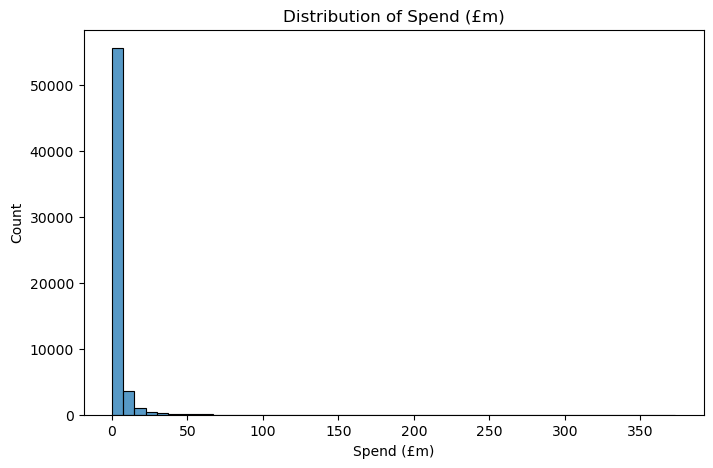

In [33]:
# Plot distribution of Spend (£m)
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["Spend (£m)"], bins=50)
plt.title("Distribution of Spend (£m)")
plt.xlabel("Spend (£m)")
plt.ylabel("Count")
plt.show()

The histogram shows that **Spend (£m)** is highly right-skewed.

Most visitor segments have relatively low spending values, while only a small number of segments have very high spending values. This means the target variable is not evenly distributed.

This is important for modelling because the models may predict the common lower spend values more easily, but may struggle with the smaller number of very high spend values. These high values can also affect the model errors later, especially metrics such as MSE and RMSE.

### Skewness of Spend (£m)

To support the histogram, I will also calculate the skewness of **Spend (£m)**.

A high positive skewness value means that the distribution has a long right tail, with some very large values compared to most observations.

In [34]:
# Check skewness of the target variable
df_clean["Spend (£m)"].skew()

10.904278604838785

The skewness value is approximately **10.90**, which confirms that **Spend (£m)** is strongly right-skewed.

This supports what was already visible in the histogram. Most values are concentrated on the lower side, but there are some very large values on the right side of the distribution.

This will be important later when evaluating the models, because large errors on high-spend observations can increase metrics such as MSE and RMSE.

### Boxplot of Spend (£m)

Next, I will use a boxplot to check for possible outliers in **Spend (£m)**.

A boxplot is useful because it shows the spread of the target variable and highlights values that are far away from the main distribution.

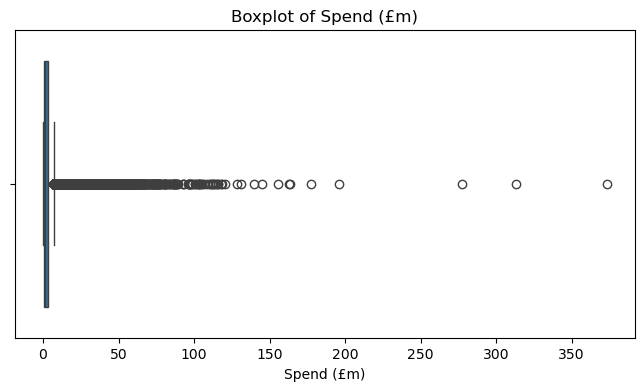

In [35]:
# Boxplot of Spend (£m)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean["Spend (£m)"])
plt.title("Boxplot of Spend (£m)")
plt.xlabel("Spend (£m)")
plt.show()

The boxplot shows several high-value observations far away from the main group of values.

These points appear as outliers in the plot, but they will not be removed at this stage because there is no clear evidence that they are data errors. They may represent valid visitor segments with unusually high spending.

For this project, I will keep these values and consider their effect later when comparing the regression model results.

### Correlation Between Numerical Variables

Now I will check the correlation between the numerical variables.

This helps to understand how variables such as **Visits (000s)**, **Nights (000s)** and **sample** relate to **Spend (£m)**.

In [36]:
# Correlation matrix for numerical columns
numeric_columns = df_clean.select_dtypes(include=[np.number]).columns

correlation_matrix = df_clean[numeric_columns].corr()
correlation_matrix

,Visits (000s),Spend (£m),Nights (000s),sample,year_clean
Visits (000s),1.000000,0.681430,0.570558,0.830621,0.099320
Spend (£m),0.681430,1.000000,0.598601,0.614725,0.143792
Nights (000s),0.570558,0.598601,1.000000,0.481264,0.077052
sample,0.830621,0.614725,0.481264,1.000000,-0.036763
year_clean,0.099320,0.143792,0.077052,-0.036763,1.000000


The correlation matrix shows that **Spend (£m)** has a positive correlation with the main numerical variables.

The strongest positive correlation with **Spend (£m)** is **Visits (000s)** at approximately **0.68**. This means that visitor segments with more visits tend to have higher spending.

**Nights (000s)** also has a positive correlation with **Spend (£m)** at approximately **0.60**, which makes sense because longer total stays can be linked with higher total spend.

The **sample** column also has a positive correlation with **Spend (£m)** at approximately **0.61**, but this column will need to be considered carefully later because it represents sample size rather than a direct visitor characteristic.

The **year_clean** column has a weaker relationship with **Spend (£m)**, with a correlation of approximately **0.14**.

### Correlation Heatmap

To make the correlations easier to understand, I will visualise them using a heatmap.

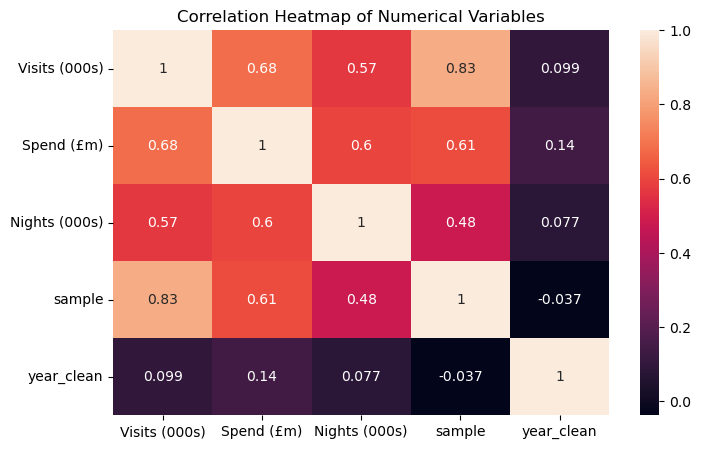

In [37]:
# Plot correlation heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

The heatmap makes the correlations easier to compare visually.

The strongest relationship in the heatmap is between **Visits (000s)** and **sample**, with a correlation of approximately **0.83**. This suggests that the sample size is closely linked with the number of visits.

For the target variable, **Spend (£m)** has the strongest positive relationships with **Visits (000s)**, **sample**, and **Nights (000s)**.

This suggests that numerical variables related to visitor volume and stay length may be useful for predicting spending. However, the **sample** column will need to be considered carefully later because it represents the survey/sample size. It may help the model statistically, but it may not be a normal visitor characteristic available when making a future prediction.

### Total Spend by Purpose

Next, I will check total **Spend (£m)** by travel purpose.

This helps to understand which purposes of visit are linked with the highest overall spending in the dataset.

In [38]:
# Total spend by purpose
spend_by_purpose = (
    df_clean.groupby("purpose")["Spend (£m)"]
    .sum()
    .sort_values(ascending=False)
)

spend_by_purpose

purpose
Holiday          85579.245305
Business         50169.127178
VFR              32014.802394
Miscellaneous    13698.417481
Study             8249.132433
Name: Spend (£m), dtype: float64

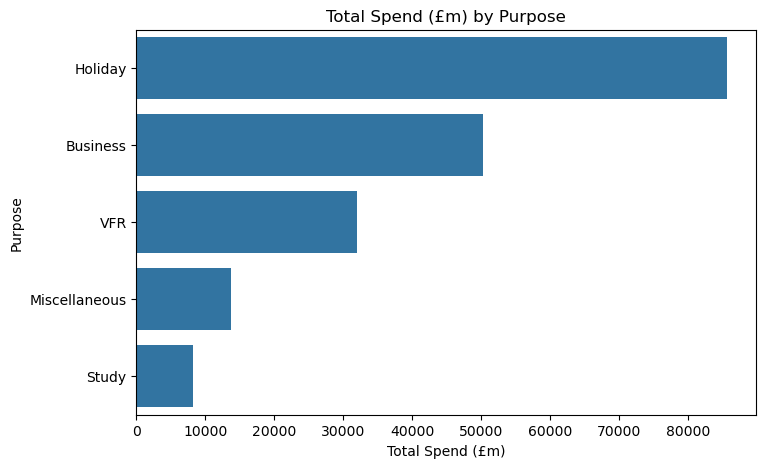

In [39]:
# Plot total spend by purpose
plt.figure(figsize=(8, 5))
sns.barplot(x=spend_by_purpose.values, y=spend_by_purpose.index)
plt.title("Total Spend (£m) by Purpose")
plt.xlabel("Total Spend (£m)")
plt.ylabel("Purpose")
plt.show()

The output and bar chart show that **Holiday** has the highest total **Spend (£m)**, with approximately **85,579**.

**Business** is the second highest category, with approximately **50,169**, followed by **VFR** with approximately **32,015**.

This suggests that travel purpose is likely to be useful for predicting visitor spending. However, this chart shows total spend by purpose, so it is influenced by both the number of observations and the spending values in each category.

### Total Spend by Mode of Transport

Next, I will check total **Spend (£m)** by mode of transport.

This helps to understand whether spending differs depending on how visitors travelled.

In [40]:
# Total spend by mode of transport
spend_by_mode = (
    df_clean.groupby("mode")["Spend (£m)"]
    .sum()
    .sort_values(ascending=False)
)

spend_by_mode

mode
Air       167786.513876
Tunnel     16220.472232
Sea         5703.738684
Name: Spend (£m), dtype: float64

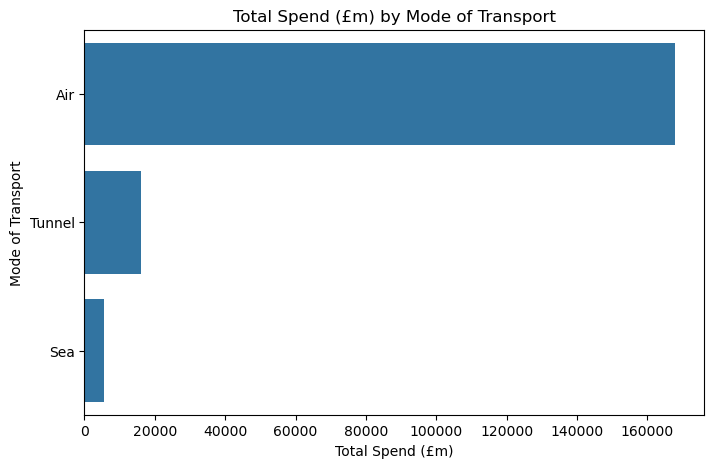

In [41]:
# Plot total spend by mode
plt.figure(figsize=(8, 5))
sns.barplot(x=spend_by_mode.values, y=spend_by_mode.index)
plt.title("Total Spend (£m) by Mode of Transport")
plt.xlabel("Total Spend (£m)")
plt.ylabel("Mode of Transport")
plt.show()

The output and bar chart show that **Air** is by far the dominant mode of transport by total **Spend (£m)**, with approximately **167,787**.

This is much higher than **Tunnel** and **Sea**. This matches the earlier value counts, where Air was also the most common mode of transport.

This suggests that mode of transport may be a useful feature for the regression models, but the result also reflects the fact that many more visitor segments travel by Air.

### Total Spend by Quarter

Next, I will check total **Spend (£m)** by quarter.

This helps to see whether visitor spending changes during different parts of the year.

In [42]:
# Total spend by quarter in chronological order
quarter_order = ["January-March", "April-June", "July-September", "October-December"]

spend_by_quarter = (
    df_clean.groupby("quarter")["Spend (£m)"]
    .sum()
    .reindex(quarter_order)
)

spend_by_quarter

quarter
January-March       39447.043648
April-June          46929.584550
July-September      55654.995775
October-December    47679.100819
Name: Spend (£m), dtype: float64

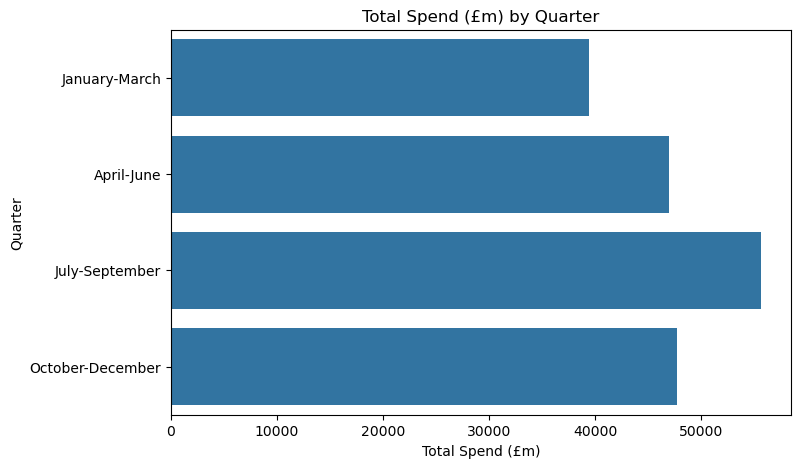

In [43]:
# Plot total spend by quarter
plt.figure(figsize=(8, 5))
sns.barplot(x=spend_by_quarter.values, y=spend_by_quarter.index)
plt.title("Total Spend (£m) by Quarter")
plt.xlabel("Total Spend (£m)")
plt.ylabel("Quarter")
plt.show()

The output and bar chart show that **July-September** has the highest total **Spend (£m)**, with approximately **55,655**.

The lowest total spend is in **January-March**, with approximately **39,447**.

Showing the quarters in calendar order makes it easier to see the seasonal pattern across the year. This suggests that the **quarter** variable may help the models understand seasonal differences in visitor spending.

### Top 10 Markets by Total Spend

Next, I will check the top 10 visitor markets by total **Spend (£m)**.

This is useful because the **market** column has many categories, and different markets may have different spending patterns.

In [44]:
# Top 10 markets by total spend
top_markets_spend = (
    df_clean.groupby("market")["Spend (£m)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_markets_spend

market
USA                     31274.394670
France                   9927.791508
Italy                    9019.596441
Germany                  8742.255439
Spain                    8036.472217
Australia                7278.042464
China                    5660.125498
United Arab Emirates     4922.583661
Irish Republic           4640.031829
Canada                   4481.224736
Name: Spend (£m), dtype: float64

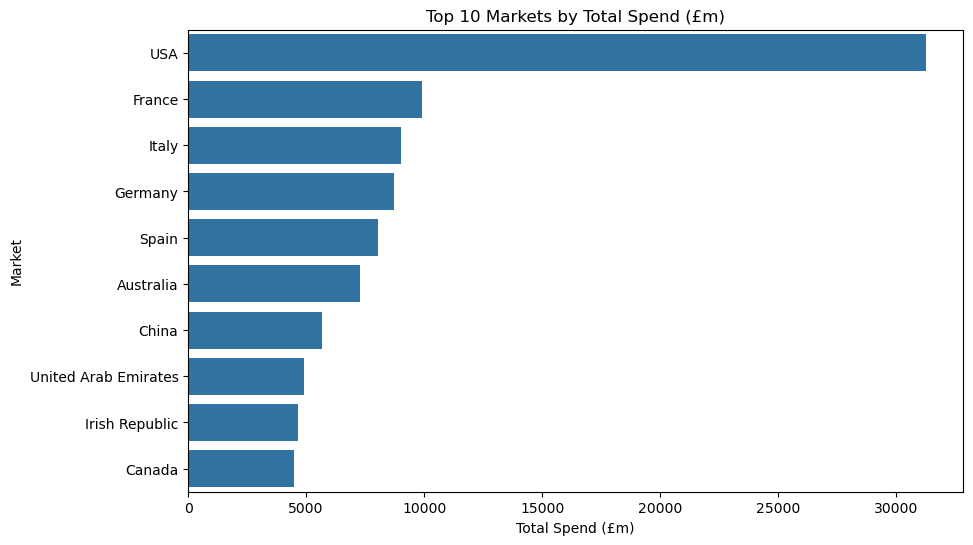

In [45]:
# Plot top 10 markets by total spend
plt.figure(figsize=(10, 6))
sns.barplot(x=top_markets_spend.values, y=top_markets_spend.index)
plt.title("Top 10 Markets by Total Spend (£m)")
plt.xlabel("Total Spend (£m)")
plt.ylabel("Market")
plt.show()

The output and bar chart show that the **USA** is the highest market by total **Spend (£m)**, with approximately **31,274**.

The USA is much higher than the second market, **France**, which has approximately **9,928**. Other important markets in the top 10 include **Italy**, **Germany**, **Spain**, **Australia**, and **China**.

This shows that the **market** column is likely to be an important feature for predicting spending. Since the market column has 62 different categories, it will need to be encoded before modelling.

### Total Spend Over Years

Next, I will check total **Spend (£m)** over the years.

This helps to understand whether spending changed over time in the dataset.

In [46]:
# Total spend by year
spend_by_year = (
    df_clean.groupby("year_clean")["Spend (£m)"]
    .sum()
    .sort_index()
)

spend_by_year

year_clean
2002     5787.853522
2003     5869.946135
2004     6439.274949
2005     6858.580913
2006     7821.599766
2007     8192.406637
2008     8125.685818
2009     8910.227327
2010     9506.843968
2011    10089.450310
2012    10941.032658
2013    12073.704493
2014    12736.999819
2015    13130.947222
2016    13815.335401
2017    16267.399177
2018    14862.869515
2019    15725.002242
2020     2555.564919
Name: Spend (£m), dtype: float64

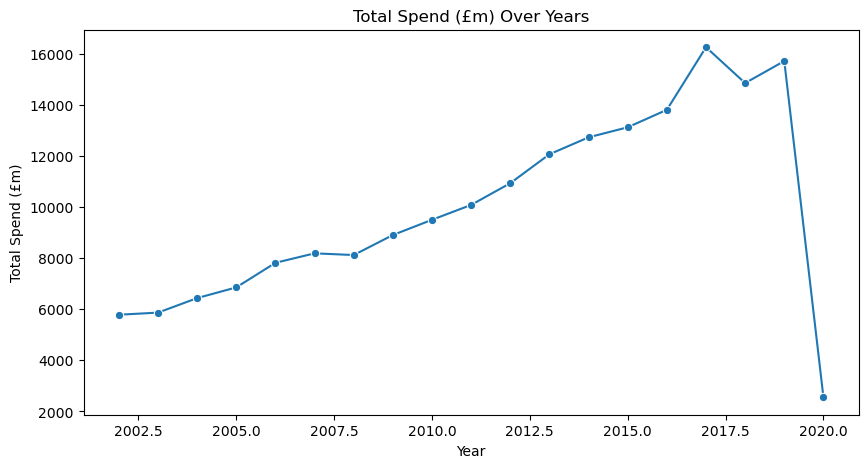

In [47]:
# Plot total spend over years
plt.figure(figsize=(10, 5))
sns.lineplot(x=spend_by_year.index, y=spend_by_year.values, marker="o")
plt.title("Total Spend (£m) Over Years")
plt.xlabel("Year")
plt.ylabel("Total Spend (£m)")
plt.show()

The line plot shows that total **Spend (£m)** generally increased from 2002 to 2017.

The highest total spend appears in **2017**, with approximately **16,267**. After that, total spend decreases in 2018, increases again in 2019, and then drops sharply in 2020.

The 2020 value should be interpreted carefully because the original dataset contained **2020P**, which appears to mean provisional or partial 2020 data. Because of this, 2020 may not be directly comparable with the earlier full years.

### Exploratory Data Analysis Summary

The exploratory data analysis helped to understand the main patterns in the cleaned dataset before modelling.

The main findings are:

- **Spend (£m)** is highly right-skewed, with a skewness value of approximately **10.90**;
- the boxplot shows several high-value observations that appear as outliers;
- these outliers were not removed because there is no clear evidence that they are data errors;
- **Spend (£m)** has positive correlations with **Visits (000s)**, **Nights (000s)** and **sample**;
- **Visits (000s)** has the strongest correlation with **Spend (£m)**, at approximately **0.68**;
- **Holiday** has the highest total spend by purpose, with approximately **85,579**;
- **Air** has the highest total spend by mode of transport, with approximately **167,787**;
- **July-September** has the highest total spend by quarter, with approximately **55,655**;
- the **USA** is the highest market by total spend, with approximately **31,274**;
- total spend generally increased over the years until 2017, but **2020** needs to be interpreted carefully because it came from **2020P**.

These total spend charts show aggregated spending, so they are useful for understanding the biggest contributing categories. However, they do not mean that every individual visitor segment in that category spends more.

These findings support the next stages of the project. The dataset contains useful numerical and categorical features, but the categorical variables will need to be encoded before modelling. The numerical variables will also need to be prepared and scaled before training the Neural Network.

## Feature Selection

After cleaning and exploring the dataset, I will now select the features that will be used for modelling.

In this project, the target variable is **Spend (£m)** because the objective is to predict visitor spending. The features are the columns that will be used to help the models make this prediction.

This step is important because machine learning models need a clear separation between the input variables and the target variable. It also helps to make sure that only useful and justified columns are used for modelling.

In the class materials, feature engineering and preparation are important steps before modelling because the raw dataset needs to be converted into a structure that the machine learning models can use (McQuaid, 2026e).

### Target Variable

The target variable for this regression task is **Spend (£m)**.

This is the value that the Linear Regression, Random Forest and Neural Network models will try to predict.

In [48]:
# Define the target variable
target_column = "Spend (£m)"

y = df_clean[target_column]

# Display the first five target values
y.head()

0    0.969138
1    2.399577
2    0.089833
3    0.010160
4    0.016789
Name: Spend (£m), dtype: float64

The target variable **Spend (£m)** was selected and stored in `y`.

The first values show the spending values that the models will try to predict. Since these values are continuous numbers, this confirms again that this part of the project is a regression task.

### Feature Selection Decision

The features selected for the main model are:

- **year_clean**
- **quarter**
- **market**
- **dur_stay**
- **mode**
- **purpose**
- **Visits (000s)**
- **Nights (000s)**

These features were selected because they describe the visitor segment and may help explain spending differences. For example, spending may change depending on the year, quarter, market, duration of stay, mode of transport, purpose of visit, number of visits and number of nights.

The **Spend (£m)** column is not included in `X` because it is the target variable.

### Decision About the sample Column

The **sample** column was not included in the main model.

Even though sample has a positive correlation with **Spend (£m)**, it represents the survey/sample size rather than a normal visitor segment characteristic.

For a future prediction of a new visitor segment, information such as market, purpose, visits and nights is more meaningful and more likely to be available. The sample value may not be available in the same way when making a new prediction.

For this reason, I decided to exclude sample from the main modelling dataset. This keeps the model focused on visitor segment features and avoids depending on a variable that may not be realistic for future use.

In [49]:
# Define the feature columns for the main model
feature_columns = [
    "year_clean",
    "quarter",
    "market",
    "dur_stay",
    "mode",
    "purpose",
    "Visits (000s)",
    "Nights (000s)"
]

# Create the feature dataset
X = df_clean[feature_columns]

# Display the first five rows of the selected features
X.head()

,year_clean,quarter,market,dur_stay,mode,purpose,Visits (000s),Nights (000s)
0,2002,January-March,Belgium,1-3 nights,Air,Holiday,3.572186,6.954456
1,2002,January-March,Belgium,1-3 nights,Air,Business,9.284226,12.604959
2,2002,January-March,Belgium,1-3 nights,Air,VFR,0.877182,2.153128
3,2002,January-March,Belgium,1-3 nights,Air,Miscellaneous,0.163874,0.163874
4,2002,January-March,Belgium,1-3 nights,Sea,Business,1.648670,1.650300


The selected feature columns were stored in `X`.

The output shows that `X` contains **8 features**. Some are numerical, such as year_clean, Visits (000s) and Nights (000s). Others are categorical, such as quarter, market, dur_stay, mode and purpose.

The categorical variables will need to be encoded before modelling because machine learning models need numerical input.

### Check Feature and Target Shapes

I will now check the shapes of `X` and `y`.

This confirms that the feature dataset and the target variable have the same number of rows.

In [50]:
# Check the shape of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (61462, 8)
y shape: (61462,)


The shape check confirms that `X` and `y` have the same number of rows: **61,462**.

The feature dataset `X` has **8 columns**, which are the selected predictor variables. The target variable `y` has one value for each row, which is **Spend (£m)**.

At this stage, the features have been selected, but the categorical columns still need to be encoded before the models can be trained.

### Feature Selection Summary

In this stage, I selected the target variable and the main features for the regression models.

The target variable is:

- Spend (£m)

The selected features are:

- year_clean
- quarter
- market
- dur_stay
- mode
- purpose
- Visits (000s)
- Nights (000s)

The sample column was not included in the main model because it represents survey/sample size rather than a normal visitor segment characteristic. This decision makes the model more realistic for a future prediction of a new visitor segment.

The next step is to prepare the selected features for modelling. This will include encoding the categorical variables and scaling numerical variables where needed.

## Encoding Categorical Data

After selecting the features, the next step is to convert the categorical variables into numerical format.

Machine learning models cannot work directly with text categories such as market, purpose, mode or quarter. These values need to be converted into numbers before the models can be trained.

In the class materials, categorical data can be encoded using different approaches. However, ordinal encoding should only be used when the categories have a meaningful order. For variables with no natural order, one-hot encoding is more suitable because it avoids creating a false ranking between categories (McQuaid, 2026d).

In this dataset, the categorical features selected for modelling are:

- quarter
- market
- dur_stay
- mode
- purpose

These variables do not have a simple numeric order. For example, Air, Sea and Tunnel are different transport modes, but one is not naturally higher or lower than the other. Because of this, I will use one-hot encoding with `pd.get_dummies()`.

### Identify Categorical and Numerical Features

Before applying encoding, I will separate the categorical and numerical columns in `X`.

This helps to confirm which columns need encoding and which columns are already numeric.

In [51]:
# Identify categorical and numerical columns in X
categorical_features = X.select_dtypes(include="object").columns
numerical_features = X.select_dtypes(include=[np.number]).columns

print("Categorical features:")
print(list(categorical_features))

print("\nNumerical features:")
print(list(numerical_features))

Categorical features:
['quarter', 'market', 'dur_stay', 'mode', 'purpose']

Numerical features:
['year_clean', 'Visits (000s)', 'Nights (000s)']


The output shows that the categorical features are quarter, market, dur_stay, mode and purpose.

The numerical features are year_clean, Visits (000s) and Nights (000s).

This confirms that only the categorical features need to be encoded before modelling.

### Apply One-Hot Encoding

I will now apply one-hot encoding using `pd.get_dummies()`.

This will create new binary columns for the categorical values. Each new column will contain Boolean values, **True** or **False**, showing whether that category is present in each row. These Boolean values work like binary indicators for the machine learning models.

I will use `drop_first=True` to avoid creating unnecessary duplicate information between dummy variables. This is commonly used with dummy variables because one category can be represented by the absence of the others.

In [52]:
# Apply one-hot encoding to categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

# Display the first five rows of the encoded dataset
X_encoded.head()

,year_clean,Visits (000s),Nights (000s),quarter_January-March,quarter_July-September,quarter_October-December,market_Australia,market_Austria,market_Bahrain,market_Belgium,market_Brazil,market_Bulgaria,market_Canada,market_Chile,market_China,market_Czech Republic,market_Denmark,market_Egypt,market_Finland,market_France,market_Germany,market_Greece,market_Hong Kong,market_Hungary,market_Iceland,market_India,market_Indonesia,market_Irish Republic,market_Israel,market_Italy,market_Japan,market_Kenya,market_Kuwait,market_Luxembourg,market_Malaysia,market_Mexico,market_Netherlands,market_New Zealand,market_Nigeria,market_Norway,market_Oman,market_Other Africa,market_Other Asia,market_Other Central & South America,market_Other Eastern Europe,market_Other Middle East,market_Other Southern Africa,market_Other Western Europe,market_Pakistan,market_Poland,market_Portugal,market_Qatar,market_Romania,market_Russia,market_Saudi Arabia,market_Serbia,market_Singapore,market_South Africa,market_South Korea,market_Spain,market_Sweden,market_Switzerland,market_Taiwan,market_Thailand,market_Turkey,market_USA,market_United Arab Emirates,dur_stay_15+ nights,dur_stay_4-7 nights,dur_stay_8-14 nights,mode_Sea,mode_Tunnel,purpose_Holiday,purpose_Miscellaneous,purpose_Study,purpose_VFR
0,2002,3.572186,6.954456,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,2002,9.284226,12.604959,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,2002,0.877182,2.153128,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,2002,0.163874,0.163874,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,2002,1.648670,1.650300,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False


The categorical variables were converted into numerical dummy variables.

The output shows that the original categorical columns were replaced by new dummy columns containing **True** and **False** values.

These Boolean values represent whether each category is present in each row. They can be used by machine learning models because they work like binary numerical indicators.

Using `drop_first=True` also keeps the encoded dataset smaller because one category from each categorical variable is dropped as the reference category.

### Check Encoded Dataset Shape

I will now check the shape of the encoded feature dataset.

This is useful because one-hot encoding increases the number of columns by creating new dummy variables for each category.

In [53]:
# Check the shape before and after encoding
print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

Original X shape: (61462, 8)
Encoded X shape: (61462, 76)


The shape check shows that the number of rows stayed the same at **61,462**, but the number of columns increased from 8 to 76 after one-hot encoding.

This is expected because categorical variables such as market, quarter, dur_stay, mode and purpose were expanded into multiple dummy variable columns.

The dataset is now closer to the format needed for modelling, because all selected features are now numeric or Boolean.

### Check Encoded Data Types

I will now check the data types after encoding to confirm that the dataset no longer contains object/text columns.

In [54]:
# Check data types after encoding
X_encoded.dtypes

year_clean                  int32
Visits (000s)             float64
Nights (000s)             float64
quarter_January-March        bool
quarter_July-September       bool
                           ...   
mode_Tunnel                  bool
purpose_Holiday              bool
purpose_Miscellaneous        bool
purpose_Study                bool
purpose_VFR                  bool
Length: 76, dtype: object

The data types show that the encoded dataset now contains numerical columns and Boolean dummy columns.

There are no object/text columns left, which means the categorical variables were successfully converted into a format that can be used for modelling.

### Check Remaining Object Columns

To confirm the encoding worked correctly, I will also check if any object columns are still present in `X_encoded`.

In [55]:
# Check if any object columns remain after encoding
X_encoded.select_dtypes(include="object").columns

Index([], dtype='object')

The output confirms that there are no remaining object columns in `X_encoded`.

This means the selected feature dataset has been successfully converted into numerical format.

### Encoding Summary

In this stage, the categorical variables were converted into numerical format using one-hot encoding.

The encoded variables were:

- quarter
- market
- dur_stay
- mode
- purpose

One-hot encoding was used because these variables do not have a natural order. This avoids creating a false ranking between categories.

The target variable **Spend (£m)** was not encoded because it is already numerical and continuous.

The encoded feature dataset is now stored as `X_encoded`. The next step is to split the data into training and testing sets, and then apply feature scaling where needed.

## Train/Test Split

After encoding the categorical variables, the next step is to split the dataset into training and testing sets.

This is important because the models should not be trained and evaluated on the same data. If the same data is used for both training and testing, the evaluation may look better than it really is.

The training set will be used to train the regression models. The testing set will be kept separate and will be used to evaluate how well the models perform on unseen data.

This follows the machine learning approach covered in the class materials and in *Introduction to Machine Learning with Python*, where the model is trained on one part of the data and tested on another part to measure generalisation and reduce the risk of overfitting (Müller and Guido, 2017).

### Split Features and Target

I already created:

- `X_encoded` as the encoded feature dataset;
- `y` as the target variable **Spend (£m)**.

Now I will split these into training and testing sets using `train_test_split`.

In [56]:
# Split the encoded features and target into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

The dataset was split into training and testing sets.

I used **80% of the data for training** and **20% of the data for testing**. The `random_state=42` was used to make the split reproducible, so the same split can be generated again when the notebook is re-run.

### Check Train and Test Shapes

I will now check the shapes of the training and testing sets.

This confirms how many rows and columns are in each part of the split.

In [57]:
# Check the shape of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (49169, 76)
X_test shape: (12293, 76)
y_train shape: (49169,)
y_test shape: (12293,)


The shape check confirms that the dataset was split correctly.

The training set contains **49,169 rows** and the test set contains **12,293 rows**. Both `X_train` and `X_test` have **76 columns**, which means the same encoded features are available in both sets.

`y_train` and `y_test` also match the number of rows in their respective feature datasets.

### Why the Test Set Is Kept Separate

The test set will not be used to train the models.

It will only be used after training, to check how well each model performs on data it has not seen before. This is important because the main goal is not just to memorise the training data, but to make good predictions for new visitor segments.

Keeping a separate test set helps to evaluate model generalisation and gives a more realistic idea of model performance.

### Train/Test Split Summary

In this stage, the encoded feature dataset and target variable were split into training and testing sets.

The main decisions were:

- `X_encoded` was used as the input feature dataset;
- `y` was used as the target variable;
- 80% of the data was used for training;
- 20% of the data was used for testing;
- `random_state=42` was used to make the split reproducible.

After the split, the training set contains **49,169 rows**, and the test set contains **12,293 rows**.

The training set will be used to fit the Linear Regression, Random Forest Regressor and Neural Network models. The testing set will be used later to compare model performance on unseen data.

The next step is feature scaling. This is mainly important for the Neural Network because the numerical variables have different ranges. For example, year_clean, Visits (000s) and Nights (000s) are not on the same scale.

Scaling will help prepare the data for the Neural Network model. A scaled version of the dataset will be created and used where needed during modelling.

## Feature Scaling

After splitting the data into training and testing sets, the next step is to apply feature scaling.

Feature scaling is important because some machine learning models are affected by the scale of the input variables. In this project, scaling is mainly important for the **Neural Network**, because Neural Networks usually train better when the input features are on a similar scale.

The numerical variables in this dataset have different ranges. For example, year_clean, Visits (000s) and Nights (000s) are not measured on the same scale. The dummy variables created during encoding are already represented as True/False values, which work like 0/1 indicators.

In the class materials, scaling is explained as an important preparation step for models that are sensitive to feature scale, including Neural Networks and some regression models (McQuaid, 2026f).

For this project, I will create a scaled version of the dataset mainly for the Neural Network model.

I will use **MinMaxScaler** because the dataset showed strong skewness during EDA and the values do not appear normally distributed. This also follows the Keras regression approach covered in class, where MinMaxScaler is suitable when the data is not normally distributed (McQuaid, 2026b).

### Apply MinMaxScaler

I will now apply `MinMaxScaler` to the training and testing feature sets.

The scaler will be fitted only on the training data using `fit_transform()`. Then, the same scaler will be used to transform the test data using `transform()`.

This is important because fitting the scaler on the test set would allow information from the test data to influence the training process. That would create data leakage.

In [58]:
# Create the MinMaxScaler object
scaler = MinMaxScaler()

# Fit the scaler only on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

The MinMaxScaler was applied correctly.

The scaler was fitted only on `X_train`, and then the same scaling rules were applied to `X_test`. This helps avoid data leakage and keeps the test set as unseen data.

### Convert Scaled Arrays Back to DataFrames

After scaling, the output becomes a NumPy array.

To make the data easier to inspect and use later, I will convert the scaled arrays back into pandas DataFrames using the same column names as `X_train` and `X_test`.

In [59]:
# Convert the scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Display the first five rows of the scaled training data
X_train_scaled.head()

,year_clean,Visits (000s),Nights (000s),quarter_January-March,quarter_July-September,quarter_October-December,market_Australia,market_Austria,market_Bahrain,market_Belgium,market_Brazil,market_Bulgaria,market_Canada,market_Chile,market_China,market_Czech Republic,market_Denmark,market_Egypt,market_Finland,market_France,market_Germany,market_Greece,market_Hong Kong,market_Hungary,market_Iceland,market_India,market_Indonesia,market_Irish Republic,market_Israel,market_Italy,market_Japan,market_Kenya,market_Kuwait,market_Luxembourg,market_Malaysia,market_Mexico,market_Netherlands,market_New Zealand,market_Nigeria,market_Norway,market_Oman,market_Other Africa,market_Other Asia,market_Other Central & South America,market_Other Eastern Europe,market_Other Middle East,market_Other Southern Africa,market_Other Western Europe,market_Pakistan,market_Poland,market_Portugal,market_Qatar,market_Romania,market_Russia,market_Saudi Arabia,market_Serbia,market_Singapore,market_South Africa,market_South Korea,market_Spain,market_Sweden,market_Switzerland,market_Taiwan,market_Thailand,market_Turkey,market_USA,market_United Arab Emirates,dur_stay_15+ nights,dur_stay_4-7 nights,dur_stay_8-14 nights,mode_Sea,mode_Tunnel,purpose_Holiday,purpose_Miscellaneous,purpose_Study,purpose_VFR
17113,0.222222,0.020865,0.009338,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38240,0.611111,0.011730,0.004454,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
58310,0.944444,0.012986,0.007718,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
47189,0.722222,0.003752,0.001065,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
18465,0.277778,0.029131,0.005107,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


The scaled training data was converted back into a pandas DataFrame.

The output shows that the values are now on a similar scale. For example, year_clean, Visits (000s) and Nights (000s) were transformed, and the dummy variable columns are now shown as 0.0 and 1.0.

The same column names were kept, which makes the dataset easier to read and use in the modelling stage.

### Check Scaled Data Shape

I will now check the shapes of the scaled training and testing datasets.

The number of rows and columns should stay the same after scaling because scaling changes the values, not the structure of the dataset.

In [60]:
# Check the shape of the scaled datasets
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (49169, 76)
X_test_scaled shape: (12293, 76)


The shape check confirms that scaling did not change the structure of the data.

`X_train_scaled` still has **49,169 rows** and **76 columns**, and `X_test_scaled` still has **12,293 rows** and **76 columns**. This means scaling changed the values, but not the number of observations or features.

### Check Scaled Values

I will now check the minimum and maximum values in the scaled training dataset.

This helps confirm that MinMaxScaler transformed the features into a similar range.

In [61]:
# Check minimum and maximum values after scaling
print("Minimum value in X_train_scaled:", X_train_scaled.min().min())
print("Maximum value in X_train_scaled:", X_train_scaled.max().max())

Minimum value in X_train_scaled: 0.0
Maximum value in X_train_scaled: 1.0000000000000002


The minimum and maximum values confirm that the training features were scaled into the expected MinMax range.

The minimum value is 0.0 and the maximum value is approximately 1.0. The very small difference above 1 is only a normal floating-point rounding effect.

This means the scaled dataset is now more suitable for the Neural Network model.

### Feature Scaling Summary

In this stage, I applied feature scaling using **MinMaxScaler**.

The main decisions were:

- scaling was applied after the train/test split;
- the scaler was fitted only on the training data;
- the test data was transformed using the same scaler;
- this was done to avoid data leakage;
- the scaled arrays were converted back into pandas DataFrames;
- the scaled datasets are stored as `X_train_scaled` and `X_test_scaled`.

After scaling, the feature values were placed on a similar range, mainly between 0 and 1. This is mainly important for the **Neural Network model**, because Neural Networks usually train better when input features are on a similar scale.

The next step is to build a standard machine learning regression model, then build the Neural Network model and compare their results.

## Modelling: Regression Baseline

After preparing the data, I will now build the first regression models.

The objective of this stage is to create baseline models that can predict **Spend (£m)** before building the Neural Network model. These baseline models will help to compare whether the Neural Network performs better or worse than standard machine learning regression models.

In this section, I will use:

- **Linear Regression**
- **Random Forest Regressor**

Linear Regression is used because it is simple, interpretable and directly linked with the Linear Regression materials covered in class (McQuaid, 2026h; McQuaid, 2026j).

Random Forest Regressor is also used because it is a traditional machine learning model that can handle more complex and non-linear relationships. The class material on Random Forest explains how combining multiple decision trees can help reduce overfitting and improve generalisation compared with a single tree (McQuaid, 2026l).

At this stage, I will train the models and generate predictions on the test set. The results will then be evaluated using regression metrics.

### Linear Regression Model

The first baseline model is **Linear Regression**.

Linear Regression is a good starting point because it is simple and easy to understand. It tries to learn a linear relationship between the selected features and the target variable **Spend (£m)**.

For this model, I will use the scaled training and testing data because Linear Regression can be affected by differences in feature scale.

In [62]:
# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model using the scaled training data
linear_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
linear_predictions = linear_model.predict(X_test_scaled)

The Linear Regression model was trained using the scaled training data.

Predictions were then generated using the scaled test data. These predictions will be compared with the real **Spend (£m)** values from `y_test`.

### Random Forest Regressor Model

The second baseline model is **Random Forest Regressor**.

Random Forest is useful because it combines multiple decision trees. This can help the model capture more complex relationships in the data compared with a simple Linear Regression model.

For this model, I will use the encoded training and testing data without scaling. This is because tree-based models such as Random Forest are not usually affected by feature scale in the same way as Neural Networks.

In [63]:
# Create the Random Forest Regressor model
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model using the encoded training data
random_forest_model.fit(X_train, y_train)

# Make predictions on the encoded test data
random_forest_predictions = random_forest_model.predict(X_test)

The Random Forest Regressor model was trained using the encoded training data.

Predictions were then generated using the encoded test data. This gives another baseline model to compare against Linear Regression and later against the Neural Network.

### Regression Evaluation Function

To evaluate the models in a consistent way, I will create a simple function to calculate common regression metrics.

The metrics used are:

- **MAE**: Mean Absolute Error;
- **MSE**: Mean Squared Error;
- **RMSE**: Root Mean Squared Error;
- **R² Score**: how well the model explains the variation in the target.

These metrics help compare how close the predictions are to the real **Spend (£m)** values.

In [64]:
# Function to evaluate regression models
def evaluate_regression_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

The evaluation function was created.

This function will make it easier to evaluate each regression model using the same metrics.

### Evaluate Baseline Models

I will now evaluate the Linear Regression and Random Forest Regressor models using the test set.

The test set was not used during training, so these results show how well the models perform on unseen data.

In [65]:
# Evaluate the baseline regression models
linear_results = evaluate_regression_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

random_forest_results = evaluate_regression_model(
    "Random Forest Regressor",
    y_test,
    random_forest_predictions
)

# Store results in a DataFrame
baseline_results = pd.DataFrame([linear_results, random_forest_results])

baseline_results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.853413,20.238099,4.498677,0.606228
1,Random Forest Regressor,1.262529,13.389468,3.659162,0.739481


The baseline model results were displayed in a DataFrame.

The **Linear Regression** model achieved an MAE of approximately 1.85, RMSE of approximately 4.50, and R² Score of approximately 0.61.

The **Random Forest Regressor** achieved a lower MAE of approximately 1.26, lower RMSE of approximately 3.66, and a higher R² Score of approximately 0.74.

This means that, at this stage, Random Forest performed better than Linear Regression on the test set. Lower MAE, MSE and RMSE values mean lower prediction error, while a higher R² Score means the model explains more variation in **Spend (£m)**.

### Baseline Model Comparison

I will now identify which baseline model performed better based on the regression metrics.

In [66]:
# Sort baseline models by RMSE
baseline_results.sort_values(by="RMSE")

,Model,MAE,MSE,RMSE,R2 Score
1,Random Forest Regressor,1.262529,13.389468,3.659162,0.739481
0,Linear Regression,1.853413,20.238099,4.498677,0.606228


The baseline models were sorted by **RMSE**.

The Random Forest Regressor had the lowest RMSE, approximately 3.66, compared with approximately 4.50 for Linear Regression.

RMSE is useful here because it penalises larger errors more strongly. This matters for this dataset because **Spend (£m)** is right-skewed and contains some high-spend observations.

Based on these baseline results, Random Forest Regressor is the stronger traditional machine learning model before building the Neural Network.

### Regression Baseline Summary

In this stage, I trained and evaluated two standard machine learning regression models:

- **Linear Regression**
- **Random Forest Regressor**

Linear Regression was used as a simple and interpretable baseline model. Random Forest Regressor was used as a stronger traditional model that can capture more complex patterns in the data.

The models were evaluated using:

- **MAE**
- **MSE**
- **RMSE**
- **R² Score**

The results showed that **Random Forest Regressor** performed better than Linear Regression on the test set. Random Forest had a lower RMSE, approximately 3.66, and a higher R² Score, approximately 0.74.

Linear Regression still gives a useful baseline, but its lower R² Score and higher errors suggest that the relationship between the selected features and **Spend (£m)** may not be fully linear.

The purpose of this stage was not to choose the final model yet, but to create baseline results that can later be compared with the Neural Network model.

The next step is to build and train the Neural Network regression model using Keras.

## Modelling: Neural Network Baseline

After building the standard regression baseline models, I will now build a Neural Network regression model using Keras.

This part is required in the assignment because the project asks for a Neural Network model to predict **Spend (£m)**.

The Neural Network will use the scaled training data because Neural Networks usually train better when the input features are on a similar scale.

The class materials on Keras follow the general sequence of defining the model, compiling it, fitting it to the training data, evaluating it and making predictions (McQuaid, 2026b).

For this first Neural Network, I will use a simple baseline structure:

- an input layer based on the number of features;
- two hidden Dense layers using ReLU activation;
- one output Dense layer with one neuron;
- `mean_squared_error` as the loss function;
- `adam` as the optimiser;
- `mae` as the evaluation metric.

This model is kept simple because the purpose is to create a first Neural Network baseline before comparing it with the standard regression models.

### Define the Neural Network Model

I will now define the Neural Network model using the Keras Sequential approach.

The input dimension is based on the number of columns in `X_train_scaled`. The output layer has one neuron because this is a regression problem and the model needs to predict one continuous value: **Spend (£m)**.

In [67]:
# Set random seed for reproducibility
tf.random.set_seed(42)

# Define the Neural Network model
nn_model = Sequential()

# Input layer
nn_model.add(Input(shape=(X_train_scaled.shape[1],)))

# First hidden layer
nn_model.add(Dense(64, activation="relu"))

# Second hidden layer
nn_model.add(Dense(32, activation="relu"))

# Output layer for regression
nn_model.add(Dense(1))

The Neural Network model was defined using `Sequential`.

The model has two hidden layers and one output layer. The output layer has one neuron because the model is predicting one numerical value.

### Compile the Neural Network Model

After defining the model structure, I will compile the model.

For this regression problem, I will use `mean_squared_error` as the loss function. I will use the `adam` optimiser because it is commonly used for Neural Networks, and I will track `mae` as an additional metric.

In [86]:
# Compile the Neural Network model
nn_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

### Check the Neural Network Structure

I will now display the model summary.

This helps to check the layers, number of parameters and input shape before training the model.

In [69]:
# Display the model structure
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           4,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,041 (27.50 KB)

 Trainable params: 7,041 (27.50 KB)

 Non-trainable params: 0 (0.00 B)

The model summary shows the structure of the Neural Network.

This confirms that the model has the correct input size and one output neuron for the regression prediction.

### Train the Neural Network Model

I will now train the Neural Network using the scaled training data.

The model will be trained for a fixed number of epochs. I will also use part of the training data as validation data so I can see how the model performs during training.

In [70]:
# Train the Neural Network model
nn_history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 34.6607 - mae: 2.3291 - val_loss: 11.6056 - val_mae: 1.8121
Epoch 2/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 21.7443 - mae: 1.7116 - val_loss: 9.8797 - val_mae: 1.6274
Epoch 3/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 19.9645 - mae: 1.5913 - val_loss: 9.0421 - val_mae: 1.5525
Epoch 4/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 18.8165 - mae: 1.5143 - val_loss: 8.5363 - val_mae: 1.5056
Epoch 5/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 18.0152 - mae: 1.4602 - val_loss: 8.2158 - val_mae: 1.4726
Epoch 6/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 17.4347 - mae: 1.4223 - val_loss: 8.0572 - val_mae: 1.4543
Epoch 7/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 16.9907 - mae: 1.3992 - val_loss: 8.0056 - val_mae: 1.4459
Epoch 8/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 16.6777 - mae: 1.3829 - val_loss: 8.0641 - val_mae: 1.4427
Epoch 9/50
1230/1230 ━━━━━━━━━━

The Neural Network model was trained for 50 epochs using the scaled training data.

The training loss reduced during the epochs, which shows that the model was learning from the training data. However, the validation loss decreased at the beginning and then started to increase again later. This suggests that the model may start to overfit after some epochs.

For this reason, a later improvement could be to use fewer epochs or add EarlyStopping, but for now this model is kept as the first Neural Network baseline.

### Make Predictions with the Neural Network

After training the model, I will use it to make predictions on the scaled test set.

The test set was not used to train the model, so these predictions can be used to evaluate performance on unseen data.

In [71]:
# Make predictions on the scaled test set
nn_predictions = nn_model.predict(X_test_scaled)

# Convert predictions to a 1D array
nn_predictions = nn_predictions.flatten()

385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


The Neural Network generated predictions for the test set.

The predictions were converted into a one-dimensional array so they can be evaluated using the same regression metrics as the baseline models.

### Evaluate the Neural Network Model

I will now evaluate the Neural Network using the same evaluation function created earlier.

Using the same metrics makes the comparison fair between Linear Regression, Random Forest Regressor and the Neural Network.

In [72]:
# Evaluate the Neural Network model
nn_results = evaluate_regression_model(
    "Neural Network Baseline",
    y_test,
    nn_predictions
)

nn_results

{'Model': 'Neural Network Baseline',
 'MAE': 1.5074438654409983,
 'MSE': 14.363304435580945,
 'RMSE': 3.789895042818593,
 'R2 Score': 0.7205333653775576}

The Neural Network baseline was evaluated using the same regression metrics as the other models.

The results show that the Neural Network performed better than Linear Regression, but it did not perform better than Random Forest Regressor in this first baseline version.

This means the Neural Network learned useful patterns from the data, but the Random Forest model still generalised better on the test set at this stage.

### Add Neural Network Results to Model Comparison

I will now add the Neural Network results to the baseline results table.

This will make it easier to compare all models together.

In [73]:
# Add Neural Network results to the baseline results DataFrame
all_model_results = pd.concat(
    [baseline_results, pd.DataFrame([nn_results])],
    ignore_index=True
)

# Display all model results
all_model_results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.853413,20.238099,4.498677,0.606228
1,Random Forest Regressor,1.262529,13.389468,3.659162,0.739481
2,Neural Network Baseline,1.507444,14.363304,3.789895,0.720533


The Neural Network results were added to the model comparison table.

The table shows that Random Forest Regressor has the strongest baseline result overall, with the lowest RMSE and highest R² Score.

The Neural Network Baseline performs better than Linear Regression, but it is still weaker than Random Forest Regressor at this stage.

This gives a useful comparison before testing whether simple Neural Network tuning can improve the result.

### Sort All Models by RMSE

I will sort the models by **RMSE** to see which model has the lowest prediction error.

In [74]:
# Sort all models by RMSE
all_model_results.sort_values(by="RMSE")

,Model,MAE,MSE,RMSE,R2 Score
1,Random Forest Regressor,1.262529,13.389468,3.659162,0.739481
2,Neural Network Baseline,1.507444,14.363304,3.789895,0.720533
0,Linear Regression,1.853413,20.238099,4.498677,0.606228


The models were sorted by **RMSE**.

The **Random Forest Regressor** had the lowest RMSE, followed by the **Neural Network Baseline**, and then **Linear Regression**.

This shows that the first Neural Network model is useful and performs better than Linear Regression, but Random Forest is still the strongest model at this stage.

Because this is only the first Neural Network baseline, the next step is to review whether a simple improvement is needed before making the final model choice.

### Neural Network Baseline Summary

In this stage, I built and trained a first Neural Network regression model using Keras.

The model used:

- a Sequential structure;
- an Input layer based on the number of features;
- two Dense hidden layers;
- ReLU activation in the hidden layers;
- one output neuron for the regression prediction;
- `mean_squared_error` as the loss function;
- `adam` as the optimiser;
- `mae` as the metric.

The Neural Network was trained using the scaled training data because Neural Networks usually work better when input features are on a similar scale.

The model performed better than Linear Regression, but it did not beat Random Forest Regressor on the test set.

The training output also suggested that the model may start to overfit after some epochs, because the validation loss increased later in training while the training loss continued to decrease.

The next step is to review the model comparison results and decide whether any simple improvement or tuning is needed before making the final model choice.

## Neural Network Tuning

After creating the first Neural Network baseline, I will now try to improve the model with simple tuning.

The assignment asks to try to improve the Neural Network model and discuss the rationale. For this reason, I will not use advanced tuning methods such as KerasTuner or a heavy grid search. Instead, I will manually test a small number of simple changes.

The tuning will focus on:

- changing the number of neurons;
- changing the number of hidden layers;
- changing the number of epochs;
- changing the batch size.

This follows a simple class-style approach. The objective is to check whether small changes to the Neural Network structure can improve the prediction of **Spend (£m)**.

### Tuned Neural Network 1: More Neurons and More Epochs

For the first tuned model, I will increase the number of neurons in the hidden layers and train the model for more epochs.

The baseline Neural Network used 64 and 32 neurons. In this tuned version, I will use 128 and 64 neurons. The idea is to give the model more capacity to learn patterns from the data.

I will also increase the number of epochs from 50 to 80 to test whether giving the model more training time improves performance. However, this may also increase the risk of overfitting, so the validation results will be reviewed carefully.

In [75]:
# Set random seed for reproducibility
tf.random.set_seed(42)

# Define Tuned Neural Network 1
nn_tuned_1 = Sequential()

# Input layer
nn_tuned_1.add(Input(shape=(X_train_scaled.shape[1],)))

# Hidden layers with more neurons
nn_tuned_1.add(Dense(128, activation="relu"))
nn_tuned_1.add(Dense(64, activation="relu"))

# Output layer for regression
nn_tuned_1.add(Dense(1))

# Compile the model
nn_tuned_1.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

# Train the model
nn_tuned_1_history = nn_tuned_1.fit(
    X_train_scaled,
    y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/80
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 30.8984 - mae: 2.1568 - val_loss: 10.8426 - val_mae: 1.7878
Epoch 2/80
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 20.5502 - mae: 1.6557 - val_loss: 9.5426 - val_mae: 1.6668
Epoch 3/80
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 18.8303 - mae: 1.5465 - val_loss: 8.8529 - val_mae: 1.5909
Epoch 4/80
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 17.8181 - mae: 1.4759 - val_loss: 8.6541 - val_mae: 1.5624
Epoch 5/80
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 17.1816 - mae: 1.4376 - val_loss: 8.5357 - val_mae: 1.5333
Epoch 6/80
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 16.7041 - mae: 1.4086 - val_loss: 8.5214 - val_mae: 1.5100
Epoch 7/80
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 16.3314 - mae: 1.3870 - val_loss: 8.7104 - val_mae: 1.5302
Epoch 8/80
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 16.0479 - mae: 1.3750 - val_loss: 8.7630 - val_mae: 1.5261
Epoch 9/80
1230/1230 ━━━━━━━━━

Tuned Neural Network 1 was trained using more neurons and more epochs than the baseline Neural Network.

The training output shows that the training loss continued to decrease during the epochs. However, the validation loss started to increase after the first few epochs. This suggests that the model was learning the training data more strongly, but it was not improving on the validation data.

This is a sign of overfitting, so adding more neurons and more epochs did not automatically improve the model.

### Evaluate Tuned Neural Network 1

I will now make predictions with Tuned Neural Network 1 and evaluate it using the same regression metrics as the previous models.

In [76]:
# Make predictions using Tuned Neural Network 1
nn_tuned_1_predictions = nn_tuned_1.predict(X_test_scaled)

# Convert predictions to a 1D array
nn_tuned_1_predictions = nn_tuned_1_predictions.flatten()

# Evaluate Tuned Neural Network 1
nn_tuned_1_results = evaluate_regression_model(
    "Neural Network Tuned 1",
    y_test,
    nn_tuned_1_predictions
)

nn_tuned_1_results

385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


{'Model': 'Neural Network Tuned 1',
 'MAE': 1.6178794195865922,
 'MSE': 18.585492937716808,
 'RMSE': 4.311089530236737,
 'R2 Score': 0.6383822965392152}

Tuned Neural Network 1 was evaluated using MAE, MSE, RMSE and R² Score.

The results were worse than the Neural Network Baseline. This shows that increasing the number of neurons and epochs made the model more complex, but did not improve test performance.

Because the validation loss increased during training and the test results became worse, this tuned model appears to overfit the training data.

### Tuned Neural Network 2: Extra Hidden Layer and Different Batch Size

For the second tuned model, I will test a slightly different structure.

This model will use three hidden layers instead of two. The idea is to check whether adding one extra layer helps the Neural Network learn more complex patterns.

I will also change the batch size from 32 to 64. This is a simple training change and helps test whether a different batch size affects the model performance.

This model is still kept simple, because the goal is not to build a very complex deep learning model.

In [77]:
# Set random seed for reproducibility
tf.random.set_seed(42)

# Define Tuned Neural Network 2
nn_tuned_2 = Sequential()

# Input layer
nn_tuned_2.add(Input(shape=(X_train_scaled.shape[1],)))

# Three hidden layers
nn_tuned_2.add(Dense(64, activation="relu"))
nn_tuned_2.add(Dense(32, activation="relu"))
nn_tuned_2.add(Dense(16, activation="relu"))

# Output layer for regression
nn_tuned_2.add(Dense(1))

# Compile the model
nn_tuned_2.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mae"]
)

# Train the model
nn_tuned_2_history = nn_tuned_2.fit(
    X_train_scaled,
    y_train,
    epochs=80,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/80
615/615 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 35.2292 - mae: 2.3247 - val_loss: 11.9253 - val_mae: 1.8317
Epoch 2/80
615/615 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 21.8613 - mae: 1.7517 - val_loss: 10.2745 - val_mae: 1.6583
Epoch 3/80
615/615 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 20.1199 - mae: 1.6257 - val_loss: 9.3630 - val_mae: 1.5614
Epoch 4/80
615/615 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 18.9701 - mae: 1.5499 - val_loss: 8.8730 - val_mae: 1.4954
Epoch 5/80
615/615 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 18.1489 - mae: 1.4992 - val_loss: 8.6151 - val_mae: 1.4643
Epoch 6/80
615/615 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 17.5365 - mae: 1.4678 - val_loss: 8.4720 - val_mae: 1.4260
Epoch 7/80
615/615 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 17.0776 - mae: 1.4433 - val_loss: 8.4857 - val_mae: 1.4161
Epoch 8/80
615/615 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 16.6983 - mae: 1.4264 - val_loss: 8.5282 - val_mae: 1.4123
Epoch 9/80
615/615 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms

Tuned Neural Network 2 was trained using an extra hidden layer and a different batch size.

The training output shows that the model continued to learn from the training data, but the validation loss did not keep improving consistently until the end. This suggests that adding an extra hidden layer and changing the batch size did not automatically make the model generalise better.

The model will now be evaluated on the same test set to check whether this simple change improved the Neural Network performance.

### Evaluate Tuned Neural Network 2

I will now make predictions with Tuned Neural Network 2 and evaluate it using the same regression metrics.

In [78]:
# Make predictions using Tuned Neural Network 2
nn_tuned_2_predictions = nn_tuned_2.predict(X_test_scaled)

# Convert predictions to a 1D array
nn_tuned_2_predictions = nn_tuned_2_predictions.flatten()

# Evaluate Tuned Neural Network 2
nn_tuned_2_results = evaluate_regression_model(
    "Neural Network Tuned 2",
    y_test,
    nn_tuned_2_predictions
)

nn_tuned_2_results

385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


{'Model': 'Neural Network Tuned 2',
 'MAE': 1.3753563260834503,
 'MSE': 16.60747867153407,
 'RMSE': 4.075227438013009,
 'R2 Score': 0.6768684953581926}

Tuned Neural Network 2 was evaluated using the same regression metrics as the other models.

The results show that this model achieved a lower MAE than the first tuned model, but its RMSE and R² Score did not improve compared with the Neural Network Baseline.

This means the extra hidden layer and different batch size helped in one metric, but did not improve the overall model performance when considering RMSE and R² Score.

### Compare All Neural Network Models

I will now compare the Neural Network baseline with the tuned Neural Network models.

This helps to check whether the tuning improved the Neural Network performance.

In [79]:
# Create a DataFrame with Neural Network results
nn_tuning_results = pd.DataFrame([
    nn_results,
    nn_tuned_1_results,
    nn_tuned_2_results
])

# Display Neural Network tuning results
nn_tuning_results

,Model,MAE,MSE,RMSE,R2 Score
0,Neural Network Baseline,1.507444,14.363304,3.789895,0.720533
1,Neural Network Tuned 1,1.617879,18.585493,4.311090,0.638382
2,Neural Network Tuned 2,1.375356,16.607479,4.075227,0.676868


The Neural Network tuning results were displayed in a DataFrame.

This table compares the Neural Network Baseline with the two tuned Neural Network models using the same evaluation metrics.

From the results, the baseline Neural Network still gives the best RMSE among the Neural Network models. Tuned Neural Network 2 has a lower MAE, but its RMSE and R² Score are weaker than the baseline. Tuned Neural Network 1 performs worse overall, which suggests that simply increasing model size and training time did not improve generalisation.

### Sort Neural Network Models by RMSE

I will now sort the Neural Network models by **RMSE**.

The model with the lowest RMSE has the lowest large-error penalty on the test set.

In [80]:
# Sort Neural Network models by RMSE
nn_tuning_results.sort_values(by="RMSE")

,Model,MAE,MSE,RMSE,R2 Score
0,Neural Network Baseline,1.507444,14.363304,3.789895,0.720533
2,Neural Network Tuned 2,1.375356,16.607479,4.075227,0.676868
1,Neural Network Tuned 1,1.617879,18.585493,4.311090,0.638382


The Neural Network models were sorted by RMSE.

Based on RMSE, the Neural Network Baseline remains the strongest Neural Network version. This is important because RMSE penalises larger errors, and the target variable Spend (£m) contains high-spend observations.

The tuned models did not improve RMSE, so the tuning results suggest that making the Neural Network more complex was not the best approach for this dataset.

### Neural Network Tuning Summary

In this stage, I performed simple Neural Network tuning.

The baseline Neural Network was compared with two tuned versions:

- **Neural Network Tuned 1** used more neurons and more epochs;
- **Neural Network Tuned 2** used an extra hidden layer and a different batch size.

The tuning was kept simple and manual. I did not use KerasTuner, CNN, RNN or heavy GridSearch because those methods would be more advanced than needed for this assignment.

The purpose of this tuning was to test whether small changes to the Neural Network architecture and training settings could improve the prediction of **Spend (£m)**.

The results showed that the tuned models did not improve the Neural Network performance overall. Tuned Neural Network 1 showed signs of overfitting, because the training loss continued to decrease while the validation loss increased later in training. Tuned Neural Network 2 achieved the lowest MAE among the Neural Network models, but it still did not beat the Neural Network Baseline when comparing RMSE and R² Score.

Because of this, the Neural Network Baseline is kept as the best Neural Network version at this stage.

This also shows that a more complex Neural Network is not always better. In this dataset, the simpler Neural Network baseline generalised better than the tuned versions.

The next step is to evaluate all models together and select the final model based on prediction performance, simplicity and suitability for the task.

## Model Evaluation

After training the standard regression models and the Neural Network models, I will now evaluate all models together.

The same evaluation metrics are used for every model. This makes the comparison fair because all models are being judged using the same test set and the same performance measures.

The metrics used are:

- **MAE**: shows the average prediction error in Spend (£m). This is easy to interpret because it is in the same unit as the target variable.
- **MSE**: shows the squared error. It penalises larger errors more strongly.
- **RMSE**: shows the square root of MSE. This is also in the same unit as Spend (£m), but it gives more weight to larger errors.
- **R² Score**: shows how much of the variation in Spend (£m) is explained by the model.

RMSE is especially useful in this project because the EDA showed that Spend (£m) is right-skewed and contains high-value observations. This means larger prediction errors are important to consider.

In [87]:
# Final model evaluation table
final_model_results = pd.DataFrame([
    linear_results,
    random_forest_results,
    nn_results,
    nn_tuned_1_results,
    nn_tuned_2_results
])

# Display final model results
final_model_results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.853413,20.238099,4.498677,0.606228
1,Random Forest Regressor,1.262529,13.389468,3.659162,0.739481
2,Neural Network Baseline,1.507444,14.363304,3.789895,0.720533
3,Neural Network Tuned 1,1.617879,18.585493,4.311090,0.638382
4,Neural Network Tuned 2,1.375356,16.607479,4.075227,0.676868


The final model results table shows the performance of all models using the same regression metrics and the same test set.

This includes the standard machine learning models and the Neural Network models, so the comparison is consistent and fair.

In [85]:
# Sort final model results by RMSE
final_model_results_sorted = final_model_results.sort_values(by="RMSE")

final_model_results_sorted

,Model,MAE,MSE,RMSE,R2 Score
1,Random Forest Regressor,1.262529,13.389468,3.659162,0.739481
2,Neural Network Baseline,1.507444,14.363304,3.789895,0.720533
4,Neural Network Tuned 2,1.375356,16.607479,4.075227,0.676868
3,Neural Network Tuned 1,1.617879,18.585493,4.311090,0.638382
0,Linear Regression,1.853413,20.238099,4.498677,0.606228


The models were sorted by RMSE because RMSE penalises larger errors more strongly.

From the results, Random Forest Regressor remains the strongest model overall. It has the lowest RMSE and the highest R² Score.

The Neural Network Baseline is the best Neural Network version based on RMSE. The tuned Neural Network models did not improve the overall result, even though Tuned Neural Network 2 achieved a lower MAE among the Neural Network models.

Linear Regression is useful as a simple baseline, but it has weaker performance than Random Forest and the Neural Network Baseline. This suggests that the relationship between the selected features and Spend (£m) is not fully linear.

### Model Evaluation Summary

In this stage, all regression models were evaluated using the same metrics: MAE, MSE, RMSE and R² Score.

The evaluation showed that Random Forest Regressor performed best overall. It achieved the lowest RMSE and the highest R² Score, which means it had the strongest balance of lower prediction error and explained variation.

The Neural Network Baseline performed better than Linear Regression and was the strongest Neural Network model based on RMSE. However, the tuned Neural Network models did not improve the result.

This shows that making the Neural Network more complex did not automatically improve performance. For this dataset, the Random Forest Regressor gave the best overall result, while the Neural Network Baseline remained useful for comparison and satisfied the Neural Network requirement of the assignment.

The next step is to select the final model and explain why it is the most suitable model for predicting Spend (£m).

## Select Final Model and Rationale

After evaluating all regression models, I will now select the final model for predicting **Spend (£m)**.

The final model selection is based on the test set results, using the same evaluation metrics for all models. This is important because the final model should not be chosen only because it is more advanced or because it is a Neural Network. It should be selected based on performance, suitability for the problem and how well it generalises to unseen data.

The models compared were:

- Linear Regression;
- Random Forest Regressor;
- Neural Network Baseline;
- Neural Network Tuned 1;
- Neural Network Tuned 2.

From the evaluation stage, the **Random Forest Regressor** achieved the strongest overall performance. It had the lowest RMSE and the highest R² Score among all models.

For this reason, I selected **Random Forest Regressor** as the final model for this regression task.

### Why RMSE Was Important

For this project, **RMSE** was one of the most important metrics for selecting the final model.

This is because the EDA showed that **Spend (£m)** is highly right-skewed and contains some high-value observations. In this type of dataset, large prediction errors are important because some visitor segments have much higher spending than most others.

RMSE is useful because it penalises larger errors more strongly than MAE. This makes it a good metric for this project, where high-spend observations can have a strong effect on model performance.

MAE was also useful because it shows the average error in the same unit as the target variable, **Spend (£m)**. However, because of the outliers and high-spend values, RMSE was more important for the final model decision.

### Final Model Choice

The final model selected is:

**Random Forest Regressor**

This model was selected because:

- it achieved the best overall test performance;
- it had the lowest RMSE;
- it had the highest R² Score;
- it performed better than Linear Regression;
- it performed better than the Neural Network models;
- it can capture non-linear relationships better than a simple linear model.

This makes sense for this dataset because visitor spending may not follow a simple straight-line relationship. Spending can be affected by several factors together, such as market, purpose, mode of transport, quarter, visits and nights.

The Random Forest Regressor is better suited to this kind of relationship because it combines multiple decision trees and can learn more complex patterns from the data.

### Why the Neural Network Was Not Selected as the Final Model

The Neural Network requirement was still completed in this project.

A Neural Network baseline was built, trained, evaluated and then tuned using two simple tuning experiments. The tuned versions tested changes such as more neurons, more epochs, an extra hidden layer and a different batch size.

However, the Neural Network models did not outperform the Random Forest Regressor.

The Neural Network Baseline was the strongest Neural Network version, but it was still weaker than Random Forest when comparing RMSE and R² Score.

Because of this, I did not select the Neural Network as the final model. This is a more realistic decision because the final model should be chosen based on results, not just because it is a Neural Network.

### Limitations of the Final Model

Although Random Forest Regressor performed best overall, there are still some limitations.

First, the target variable **Spend (£m)** is highly right-skewed. This means that most values are low, but some visitor segments have very high spending. These high-spend observations can still be difficult for any model to predict accurately.

Second, the model uses aggregated visitor segment data, not individual visitor data. This means the prediction is for a visitor segment, not for one individual tourist.

Third, the **sample** column was not included in the main model because it represents survey/sample size rather than a normal visitor segment characteristic. This makes the model more realistic for future prediction, but it also means one correlated variable was not used.

Fourth, the year **2020P** was converted to 2020, but it may represent provisional or partial data. This means 2020 should still be interpreted carefully.

Finally, Random Forest is less simple to interpret than Linear Regression. It gives better performance, but it is not as easy to explain using simple coefficients.

### Final Model Selection Summary

In this stage, I selected the **Random Forest Regressor** as the final model for predicting **Spend (£m)**.

This decision was based on the model evaluation results. Random Forest achieved the strongest overall performance, with the lowest RMSE and highest R² Score.

The Neural Network models were still important because the assignment required a Neural Network model and comparison. However, the results showed that the Neural Network did not outperform Random Forest for this dataset.

This shows that a more advanced model is not always the best model. For this project, Random Forest gave the best balance between prediction performance and suitability for the visitor spending regression problem.

The next step is to use the selected final model to make a prediction for a new visitor segment.